# Individual campaign postprocessing — v5

Reusable notebook for analysing one individual mutation campaign against the original Sanz ansätze, all evaluated under the same Local-X trainability benchmark.

The notebook performs the complete per-campaign workflow:

1. loads campaign scientific metrics and its \(L=1\) structural report;
2. reconstructs \(L=2\) and \(L=3\) by repeating the complete mutated child;
3. reconstructs the 57 original Sanz circuits from the canonical 19-template definitions;
4. calculates campaign and Sanz-reference costs;
5. reconstructs the baseline Pareto frontiers for cost thresholds \(1.0\), \(0.2\), and \(0.1\);
6. classifies each campaign circuit as discard, expressibility improvement, trainability improvement, or new Pareto optimal;
7. produces all requested per-campaign plots;
8. exports canonical tables for later cross-campaign analysis.

Only the **configuration cell** should need editing for another compatible campaign.


## Scientific definitions

\[
E=-\log_{10}(D_{\mathrm{KL}})
\]

\[
S=E\,T
\]

\[
\operatorname{Cost}
=
\alpha\,\mathcal N(N_{\mathrm{param}})
+
\beta\,\mathcal N(\mathrm{Depth})
+
\gamma\,\mathcal N(N_{2q}),
\qquad
\alpha=\beta=\gamma=\frac13
\]

\[
\mathcal N(x)=\frac{x-x_{\min}}{x_{\max}-x_{\min}}
\]

Two cost columns are retained:

- `cost_norm_campaign`: min–max ranges obtained from the current campaign.
- `cost_norm_reference`: min–max ranges obtained from the complete 57-circuit Sanz reference set.

All baseline comparisons and cost filters use `cost_norm_reference`.


## Trainability benchmark used in this analysis

All trainability values in the baseline and in the campaign are evaluated with the same Local-X Hamiltonian:

\[
H_X=\sum_{i=0}^{n-1} X_i.
\]

The corresponding trainability score is interpreted as

\[
T=\frac{1}{|P|}
\sum_{k\in P}
\operatorname{Var}\!\left[
\frac{\partial\langle H_X\rangle}{\partial\theta_k}
\right].
\]

This is a local, non-interacting benchmark. It is used here because it provides a homogeneous and computationally efficient comparison across a large number of circuit architectures and mutations. The resulting trainability scores, composite scores, rankings, and Pareto frontiers are therefore specific to Local-X and should not be interpreted as a reproduction of the TFIM frontier reported in the main Sanz figure.


In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable
import hashlib
import json
import math
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Publication-quality Matplotlib defaults.
plt.rcParams.update(
    {
        "figure.dpi": 170,
        "savefig.dpi": 600,
        "font.size": 10.5,
        "axes.titlesize": 13.0,
        "axes.labelsize": 11.5,
        "axes.linewidth": 0.9,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.fontsize": 9.0,
        "legend.title_fontsize": 9.5,
        "lines.linewidth": 1.8,
        "lines.markersize": 5.0,
        "patch.linewidth": 0.8,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "mathtext.fontset": "stix",
        "font.family": "DejaVu Sans",
    }
)

TRAINABILITY_AXIS_LABEL = (
    "Trainability\n"
    r"$T=\frac{1}{|P|}\sum_{k\in P}"
    r"\mathrm{Var}\!\left[\partial_{\theta_k}"
    r"\langle H_X\rangle\right]$"
)

EXPRESSIBILITY_AXIS_LABEL = (
    "Expressibility\n"
    r"$E=-\log_{10}\!\left(D_{\mathrm{KL}}\right)$"
)


## 1. Configuration

In [2]:
# ---------------------------------------------------------------------
# Change this cell for another individual campaign.
# ---------------------------------------------------------------------

CAMPAIGN_ID = "CX-01"

DATA_DIR = Path(".")
CAMPAIGN_METRICS_CSV = DATA_DIR / "cx_01_metrics_L123.csv"
CAMPAIGN_REPORT_JSON = DATA_DIR / "CX-01_report.json"

SANZ_REFERENCE_METRICS_CSV = DATA_DIR / "sanz19_reference_metrics_L123.csv"
SANZ_ORIGINAL_PARETO_CSV = DATA_DIR / "sanz19_original_pareto.csv"
SANZ_SOURCE_PY = DATA_DIR / "ansatzes_unified.py"

N_QUBITS = 4
LAYER_EXPANSION_MODE = "repeat_complete_child"

COST_WEIGHTS = {
    "parameter_count": 1.0 / 3.0,
    "depth": 1.0 / 3.0,
    "two_qubit_gate_count": 1.0 / 3.0,
}
COST_THRESHOLDS = (1.0, 0.2, 0.1)
NUMERICAL_TOLERANCE = 1e-12

# Trainability benchmark metadata.
TRAINABILITY_HAMILTONIAN_ID = "local_x"
TRAINABILITY_HAMILTONIAN_DEFINITION = "sum_i X_i"
TRAINABILITY_PARAMETER_AGGREGATION = "mean_variance_over_all_trainable_parameters"
REFERENCE_CONTEXT_LABEL = "Sanz ansatz family evaluated under Local-X"


OUTPUT_ROOT = DATA_DIR / "postprocessing_outputs_v5"
OUTPUT_DIR = OUTPUT_ROOT / CAMPAIGN_ID
DATA_OUTPUT_DIR = OUTPUT_DIR / "data"
BASELINE_OUTPUT_DIR = OUTPUT_DIR / "baseline"
CLASSIFICATION_OUTPUT_DIR = OUTPUT_DIR / "classifications"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
PLOT_DATA_DIR = OUTPUT_DIR / "plot_data"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"

FIGURE_FORMATS = ("png", "pdf", "svg")
FIGURE_DPI = 600
SHOW_PLOTS = True

for directory in (
    DATA_OUTPUT_DIR,
    BASELINE_OUTPUT_DIR,
    CLASSIFICATION_OUTPUT_DIR,
    TABLE_OUTPUT_DIR,
    PLOT_DATA_DIR,
    FIGURE_OUTPUT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Campaign: {CAMPAIGN_ID}")
print(f"Output:   {OUTPUT_DIR.resolve()}")


Campaign: CX-01
Output:   /mnt/data/postprocessing_outputs_v5/CX-01


## 2. Generic utilities

In [3]:
def require_file(path: Path, label: str) -> None:
    if not path.is_file():
        raise FileNotFoundError(
            f"{label} not found: {path.resolve()}\n"
            "Update the configuration cell."
        )


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def threshold_label(threshold: float) -> str:
    return str(threshold).replace(".", "p")


def minmax_normalize(
    series: pd.Series,
    *,
    minimum: float | None = None,
    maximum: float | None = None,
) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    x_min = float(values.min()) if minimum is None else float(minimum)
    x_max = float(values.max()) if maximum is None else float(maximum)

    if not np.isfinite(x_min) or not np.isfinite(x_max):
        raise ValueError(f"Invalid normalization range for {series.name!r}.")

    if np.isclose(x_max, x_min):
        return pd.Series(0.0, index=series.index, dtype=float)

    return (values - x_min) / (x_max - x_min)


def compute_depth(
    operations: list[dict[str, Any]],
    n_qubits: int,
) -> int:
    """Logical depth from wire dependencies.

    Disjoint operations may occupy the same depth level. No transpiler
    decomposition, routing, cancellation, or hardware scheduling is applied.
    """
    if n_qubits <= 0:
        raise ValueError("n_qubits must be positive.")

    wire_depth = [0] * n_qubits

    for operation in operations:
        wires = tuple(int(w) for w in operation.get("wires", ()))
        if not wires:
            continue
        if any(w < 0 or w >= n_qubits for w in wires):
            raise ValueError(f"Invalid wire in operation: {operation}")

        level = max(wire_depth[w] for w in wires) + 1
        for wire in wires:
            wire_depth[wire] = level

    return max(wire_depth, default=0)


def repeat_operations(
    operations_l1: list[dict[str, Any]],
    layer_count: int,
) -> list[dict[str, Any]]:
    if layer_count <= 0:
        raise ValueError("layer_count must be positive.")

    repeated: list[dict[str, Any]] = []
    for repeated_layer in range(layer_count):
        for operation in operations_l1:
            copied = dict(operation)
            copied["repeated_layer"] = repeated_layer
            repeated.append(copied)
    return repeated


def pareto_mask(
    frame: pd.DataFrame,
    objectives: dict[str, str],
    tolerance: float = NUMERICAL_TOLERANCE,
) -> pd.Series:
    """Return True for non-dominated rows.

    Directions must be either 'max' or 'min'. Exact duplicate points are
    retained as Pareto members.
    """
    if frame.empty:
        return pd.Series(False, index=frame.index, dtype=bool)

    bad_directions = {
        direction
        for direction in objectives.values()
        if direction not in {"max", "min"}
    }
    if bad_directions:
        raise ValueError(f"Invalid objective directions: {bad_directions}")

    values = frame[list(objectives)].to_numpy(dtype=float)
    signs = np.array(
        [
            1.0 if objectives[column] == "max" else -1.0
            for column in objectives
        ]
    )
    maximized = values * signs

    result = np.ones(len(frame), dtype=bool)

    for index, candidate in enumerate(maximized):
        no_worse = np.all(
            maximized >= candidate - tolerance,
            axis=1,
        )
        strictly_better = np.any(
            maximized > candidate + tolerance,
            axis=1,
        )
        if np.any(no_worse & strictly_better):
            result[index] = False

    return pd.Series(result, index=frame.index, dtype=bool)


def dominates(
    first: np.ndarray,
    second: np.ndarray,
    tolerance: float = NUMERICAL_TOLERANCE,
) -> bool:
    return bool(
        np.all(first >= second - tolerance)
        and np.any(first > second + tolerance)
    )


def sorted_frontier(frame: pd.DataFrame) -> pd.DataFrame:
    """Sort a Pareto frontier from left to right in the canonical plots."""
    return frame.sort_values(
        ["trainability_score", "expressibility_score"],
        ascending=[True, False],
    ).reset_index(drop=True)


def save_figure(fig: plt.Figure, stem: str) -> None:
    for extension in FIGURE_FORMATS:
        fig.savefig(
            FIGURE_OUTPUT_DIR / f"{stem}.{extension}",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )


def finalize_figure(fig: plt.Figure, stem: str) -> None:
    save_figure(fig, stem)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def axis_limits_with_margin(
    frames: Iterable[pd.DataFrame],
    x_column: str,
    y_column: str,
    margin_fraction: float = 0.05,
) -> tuple[tuple[float, float], tuple[float, float]]:
    combined = pd.concat(
        [frame[[x_column, y_column]] for frame in frames],
        ignore_index=True,
    )
    x_min, x_max = combined[x_column].min(), combined[x_column].max()
    y_min, y_max = combined[y_column].min(), combined[y_column].max()

    x_span = max(float(x_max - x_min), 1e-9)
    y_span = max(float(y_max - y_min), 1e-9)

    return (
        (
            float(x_min - margin_fraction * x_span),
            float(x_max + margin_fraction * x_span),
        ),
        (
            float(y_min - margin_fraction * y_span),
            float(y_max + margin_fraction * y_span),
        ),
    )



def annotate_non_overlapping(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    fontsize: float = 7.0,
    point_color: str = "0.2",
) -> list[Any]:
    """Place labels using collision-tested offsets in display coordinates.

    Bounding boxes are estimated before creating the annotations, making the
    procedure fast enough for notebook-wide figure regeneration. Labels are
    kept inside the axes and linked to their point with restrained leader lines.
    """
    if frame.empty:
        return []

    from matplotlib.font_manager import FontProperties
    from matplotlib.transforms import Bbox

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer)
    pixels_per_point = fig.dpi / 72.0
    font_properties = FontProperties(size=fontsize)

    candidate_offsets = [
        (8, 8), (8, -10), (-8, 8), (-8, -10),
        (14, 16), (14, -18), (-14, 16), (-14, -18),
        (22, 8), (22, -10), (-22, 8), (-22, -10),
        (8, 26), (8, -28), (-8, 26), (-8, -28),
        (30, 18), (30, -20), (-30, 18), (-30, -20),
        (42, 8), (42, -10), (-42, 8), (-42, -10),
    ]

    placed_boxes: list[Bbox] = []
    annotations: list[Any] = []

    ordered = frame.sort_values(
        [x_column, y_column],
        ascending=[True, False],
    ).reset_index(drop=True)

    for position, row in ordered.iterrows():
        x_value = float(row[x_column])
        y_value = float(row[y_column])
        label = str(row[label_column])
        point_x, point_y = ax.transData.transform((x_value, y_value))

        width, height, descent = renderer.get_text_width_height_descent(
            label,
            font_properties,
            ismath=False,
        )
        width += 7.0
        height += 5.0

        selected_offset = None
        selected_box = None

        for dx, dy in candidate_offsets:
            offset_x = dx * pixels_per_point
            offset_y = dy * pixels_per_point

            left = point_x + offset_x if dx >= 0 else point_x + offset_x - width
            bottom = point_y + offset_y if dy >= 0 else point_y + offset_y - height
            box = Bbox.from_bounds(left, bottom, width, height).expanded(1.04, 1.10)

            inside_axes = (
                box.x0 >= axes_bbox.x0
                and box.x1 <= axes_bbox.x1
                and box.y0 >= axes_bbox.y0
                and box.y1 <= axes_bbox.y1
            )
            overlaps = any(box.overlaps(other) for other in placed_boxes)

            if inside_axes and not overlaps:
                selected_offset = (dx, dy)
                selected_box = box
                break

        if selected_offset is None:
            dx, dy = candidate_offsets[position % len(candidate_offsets)]
            ring = 1 + position // len(candidate_offsets)
            dx = dx + (8 * ring if dx >= 0 else -8 * ring)
            dy = dy + (7 * ring if dy >= 0 else -7 * ring)
            selected_offset = (dx, dy)

            offset_x = dx * pixels_per_point
            offset_y = dy * pixels_per_point
            left = point_x + offset_x if dx >= 0 else point_x + offset_x - width
            bottom = point_y + offset_y if dy >= 0 else point_y + offset_y - height
            selected_box = Bbox.from_bounds(left, bottom, width, height).expanded(1.04, 1.10)

        dx, dy = selected_offset
        annotation = ax.annotate(
            label,
            xy=(x_value, y_value),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
            fontsize=fontsize,
            color="0.15",
            bbox={
                "boxstyle": "round,pad=0.18",
                "facecolor": "white",
                "edgecolor": "0.72",
                "linewidth": 0.45,
                "alpha": 0.94,
            },
            arrowprops={
                "arrowstyle": "-",
                "color": point_color,
                "linewidth": 0.45,
                "alpha": 0.75,
                "shrinkA": 1.5,
                "shrinkB": 2.0,
            },
            annotation_clip=True,
            zorder=20,
        )
        placed_boxes.append(selected_box)
        annotations.append(annotation)

    return annotations



def compact_circuit_label(circuit_id: str) -> str:
    """Shorten campaign IDs for figures while preserving uniqueness."""
    value = str(circuit_id)
    match = re.fullmatch(
        r"SANZ19-(A\d{2})-L(\d+)_G\d+-V(\d+)",
        value,
    )
    if match:
        template, layer, variant = match.groups()
        return f"{template}-L{layer}/V{int(variant):03d}"
    return value


def spread_label_positions(
    values: np.ndarray,
    *,
    lower: float,
    upper: float,
    minimum_separation: float,
) -> np.ndarray:
    """Spread ordered label positions inside fixed vertical bounds."""
    if len(values) == 0:
        return values

    positions = np.clip(np.asarray(values, dtype=float), lower, upper)
    order = np.argsort(positions)
    sorted_positions = positions[order].copy()

    for index in range(1, len(sorted_positions)):
        sorted_positions[index] = max(
            sorted_positions[index],
            sorted_positions[index - 1] + minimum_separation,
        )

    if sorted_positions[-1] > upper:
        sorted_positions -= sorted_positions[-1] - upper

    for index in range(len(sorted_positions) - 2, -1, -1):
        sorted_positions[index] = min(
            sorted_positions[index],
            sorted_positions[index + 1] - minimum_separation,
        )

    if sorted_positions[0] < lower:
        sorted_positions += lower - sorted_positions[0]

    result = np.empty_like(sorted_positions)
    result[order] = sorted_positions
    return result


def annotate_in_side_columns(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    fontsize: float = 6.6,
) -> list[Any]:
    """Place all labels in balanced left/right columns without overlap."""
    if frame.empty:
        return []

    ordered = frame.sort_values(x_column).reset_index(drop=True)
    split = int(np.ceil(len(ordered) / 2))
    groups = {
        "left": ordered.iloc[:split].copy(),
        "right": ordered.iloc[split:].copy(),
    }

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_span = x_max - x_min
    y_span = y_max - y_min

    extended_x_min = x_min - 0.24 * x_span
    extended_x_max = x_max + 0.24 * x_span
    ax.set_xlim(extended_x_min, extended_x_max)

    label_x = {
        "left": extended_x_min + 0.018 * (extended_x_max - extended_x_min),
        "right": extended_x_max - 0.018 * (extended_x_max - extended_x_min),
    }

    annotations: list[Any] = []

    for side, subset in groups.items():
        if subset.empty:
            continue

        lower = y_min + 0.035 * y_span
        upper = y_max - 0.035 * y_span
        adaptive_separation = min(
            0.052 * y_span,
            0.92 * (upper - lower) / max(len(subset) - 1, 1),
        )
        target_y = spread_label_positions(
            subset[y_column].to_numpy(dtype=float),
            lower=lower,
            upper=upper,
            minimum_separation=adaptive_separation,
        )

        for (_, row), y_text in zip(subset.iterrows(), target_y):
            is_left = side == "left"
            annotation = ax.annotate(
                str(row[label_column]),
                xy=(float(row[x_column]), float(row[y_column])),
                xytext=(label_x[side], float(y_text)),
                textcoords="data",
                ha="left" if is_left else "right",
                va="center",
                fontsize=fontsize,
                color="0.15",
                bbox={
                    "boxstyle": "round,pad=0.16",
                    "facecolor": "white",
                    "edgecolor": "0.76",
                    "linewidth": 0.4,
                    "alpha": 0.96,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": "0.55",
                    "linewidth": 0.42,
                    "alpha": 0.72,
                    "shrinkA": 1.0,
                    "shrinkB": 2.0,
                    "connectionstyle": "arc3,rad=0.0",
                },
                annotation_clip=False,
                zorder=20,
            )
            annotations.append(annotation)

    return annotations


def format_plot_circuit_id(circuit_id: Any) -> str:
    """Return a compact plot label without dataset/source prefixes.

    The canonical circuit ID remains unchanged in dataframes and exports.
    """
    label = str(circuit_id)
    label = re.sub(r"^SANZ19-", "", label, flags=re.IGNORECASE)
    label = re.sub(r"^SANZ-", "", label, flags=re.IGNORECASE)
    return label


def annotate_non_overlapping_far(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    fontsize: float = 7.0,
    point_color: str = "0.2",
) -> list[Any]:
    """Like annotate_non_overlapping, but with slightly larger offsets."""
    if frame.empty:
        return []

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer)

    candidate_offsets = [
        (14, 14), (14, -16), (-14, 14), (-14, -16),
        (22, 18), (22, -20), (-22, 18), (-22, -20),
        (30, 12), (30, -14), (-30, 12), (-30, -14),
        (12, 30), (12, -32), (-12, 30), (-12, -32),
        (36, 22), (36, -24), (-36, 22), (-36, -24),
    ]

    placed_boxes = []
    annotations = []

    ordered = frame.sort_values(
        [x_column, y_column],
        ascending=[True, False],
    ).reset_index(drop=True)

    for position, row in ordered.iterrows():
        x_value = float(row[x_column])
        y_value = float(row[y_column])
        label = str(row[label_column])
        accepted = None

        for dx, dy in candidate_offsets:
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=fontsize,
                color="0.15",
                bbox={
                    "boxstyle": "round,pad=0.18",
                    "facecolor": "white",
                    "edgecolor": "0.72",
                    "linewidth": 0.45,
                    "alpha": 0.94,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": point_color,
                    "linewidth": 0.45,
                    "alpha": 0.75,
                    "shrinkA": 1.5,
                    "shrinkB": 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )

            fig.canvas.draw()
            box = annotation.get_window_extent(renderer).expanded(1.04, 1.10)

            inside_axes = (
                box.x0 >= axes_bbox.x0
                and box.x1 <= axes_bbox.x1
                and box.y0 >= axes_bbox.y0
                and box.y1 <= axes_bbox.y1
            )
            overlaps = any(box.overlaps(other) for other in placed_boxes)

            if inside_axes and not overlaps:
                accepted = annotation
                placed_boxes.append(box)
                annotations.append(annotation)
                break

            annotation.remove()

        if accepted is None:
            dx, dy = candidate_offsets[position % len(candidate_offsets)]
            vertical_step = 9 * (position // len(candidate_offsets))
            dy = dy + vertical_step if dy >= 0 else dy - vertical_step

            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=fontsize,
                color="0.15",
                bbox={
                    "boxstyle": "round,pad=0.18",
                    "facecolor": "white",
                    "edgecolor": "0.72",
                    "linewidth": 0.45,
                    "alpha": 0.94,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": point_color,
                    "linewidth": 0.45,
                    "alpha": 0.75,
                    "shrinkA": 1.5,
                    "shrinkB": 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            placed_boxes.append(
                annotation.get_window_extent(renderer).expanded(1.04, 1.10)
            )
            annotations.append(annotation)

    return annotations


def annotate_side_columns(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    side_column: str,
    fontsize: float = 7.2,
    line_color: str = "#6E6E6E",
) -> list[Any]:
    """Place labels in left/right external columns with guide lines."""
    if frame.empty:
        return []

    annotations = []
    for side in ("left", "right"):
        subset = frame.loc[frame[side_column] == side].copy()
        if subset.empty:
            continue

        subset = subset.sort_values(y_column, ascending=False).reset_index(drop=True)
        y_positions = np.linspace(0.90, 0.12, len(subset))
        x_text = -0.25 if side == "left" else 1.04
        ha = "right" if side == "left" else "left"

        for (_, row), y_axes in zip(subset.iterrows(), y_positions):
            annotation = ax.annotate(
                str(row[label_column]),
                xy=(float(row[x_column]), float(row[y_column])),
                xycoords="data",
                xytext=(x_text, float(y_axes)),
                textcoords="axes fraction",
                ha=ha,
                va="center",
                fontsize=fontsize,
                color="0.15",
                bbox={
                    "boxstyle": "round,pad=0.18",
                    "facecolor": "white",
                    "edgecolor": "0.72",
                    "linewidth": 0.45,
                    "alpha": 0.95,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": line_color,
                    "linewidth": 0.50,
                    "alpha": 0.78,
                    "shrinkA": 1.5,
                    "shrinkB": 1.8,
                    "connectionstyle": "arc3,rad=0.0",
                },
                annotation_clip=False,
                zorder=20,
            )
            annotations.append(annotation)

    return annotations


def boxes_overlap(box_a: tuple[float, float, float, float], box_b: tuple[float, float, float, float]) -> bool:
    ax0, ay0, ax1, ay1 = box_a
    bx0, by0, bx1, by1 = box_b
    return not (ax1 < bx0 or bx1 < ax0 or ay1 < by0 or by1 < ay0)


def make_point_protection_boxes(
    ax: plt.Axes,
    x_values: Iterable[float],
    y_values: Iterable[float],
    radius_px: float = 8.0,
) -> list[tuple[float, float, float, float]]:
    transform = ax.transData.transform
    boxes = []
    for x_value, y_value in zip(x_values, y_values):
        x_disp, y_disp = transform((float(x_value), float(y_value)))
        boxes.append(
            (
                x_disp - radius_px,
                y_disp - radius_px,
                x_disp + radius_px,
                y_disp + radius_px,
            )
        )
    return boxes


def make_axes_fraction_box(
    ax: plt.Axes,
    left: float,
    bottom: float,
    right: float,
    top: float,
) -> tuple[float, float, float, float]:
    axes_bbox = ax.get_window_extent(ax.figure.canvas.get_renderer())
    return (
        axes_bbox.x0 + left * axes_bbox.width,
        axes_bbox.y0 + bottom * axes_bbox.height,
        axes_bbox.x0 + right * axes_bbox.width,
        axes_bbox.y0 + top * axes_bbox.height,
    )


def annotate_non_overlapping_protected(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    fontsize: float = 7.0,
    point_color: str = '0.2',
    point_boxes: list[tuple[float, float, float, float]] | None = None,
    reserved_boxes: list[tuple[float, float, float, float]] | None = None,
) -> list[Any]:
    if frame.empty:
        return []

    point_boxes = [] if point_boxes is None else list(point_boxes)
    reserved_boxes = [] if reserved_boxes is None else list(reserved_boxes)

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer)

    candidate_offsets = [
        (16, 16), (16, -18), (-16, 16), (-16, -18),
        (26, 10), (26, -12), (-26, 10), (-26, -12),
        (10, 28), (10, -30), (-10, 28), (-10, -30),
        (34, 20), (34, -22), (-34, 20), (-34, -22),
        (44, 12), (44, -14), (-44, 12), (-44, -14),
    ]

    placed_boxes: list[tuple[float, float, float, float]] = []
    annotations = []

    ordered = frame.sort_values([y_column, x_column], ascending=[False, True]).reset_index(drop=True)

    for position, row in ordered.iterrows():
        x_value = float(row[x_column])
        y_value = float(row[y_column])
        label = str(row[label_column])
        accepted = None

        for dx, dy in candidate_offsets:
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.18',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.45,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': point_color,
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = annotation.get_window_extent(renderer).expanded(1.05, 1.12)
            box = (bbox.x0, bbox.y0, bbox.x1, bbox.y1)
            inside_axes = (
                box[0] >= axes_bbox.x0 and box[2] <= axes_bbox.x1 and box[1] >= axes_bbox.y0 and box[3] <= axes_bbox.y1
            )
            overlaps_label = any(boxes_overlap(box, other) for other in placed_boxes)
            overlaps_point = any(boxes_overlap(box, other) for other in point_boxes)
            overlaps_reserved = any(boxes_overlap(box, other) for other in reserved_boxes)
            if inside_axes and not overlaps_label and not overlaps_point and not overlaps_reserved:
                accepted = annotation
                placed_boxes.append(box)
                annotations.append(annotation)
                break
            annotation.remove()

        if accepted is None:
            dx, dy = candidate_offsets[position % len(candidate_offsets)]
            step = 8 * (position // len(candidate_offsets))
            dy = dy + step if dy >= 0 else dy - step
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.18',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.45,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': point_color,
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = annotation.get_window_extent(renderer).expanded(1.05, 1.12)
            placed_boxes.append((bbox.x0, bbox.y0, bbox.x1, bbox.y1))
            annotations.append(annotation)

    return annotations


def annotate_inside_with_color_dots(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    thresholds_column: str,
    frontier_colors: dict[float, str],
    fontsize: float = 7.0,
    point_boxes: list[tuple[float, float, float, float]] | None = None,
    reserved_boxes: list[tuple[float, float, float, float]] | None = None,
) -> list[Any]:
    if frame.empty:
        return []

    point_boxes = [] if point_boxes is None else list(point_boxes)
    reserved_boxes = [] if reserved_boxes is None else list(reserved_boxes)

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer)
    x_mid = float(frame[x_column].median())

    placed_boxes: list[tuple[float, float, float, float]] = []
    created: list[Any] = []

    positive_offsets = [(14, 10), (14, -12), (22, 18), (22, -20), (30, 6), (30, -8), (10, 26), (10, -28)]
    negative_offsets = [(-14, 10), (-14, -12), (-22, 18), (-22, -20), (-30, 6), (-30, -8), (-10, 26), (-10, -28)]

    ordered = frame.sort_values([y_column, x_column], ascending=[False, True]).reset_index(drop=True)

    for position, row in ordered.iterrows():
        x_value = float(row[x_column])
        y_value = float(row[y_column])
        label = str(row[label_column])
        thresholds = sorted(set(float(v) for v in row[thresholds_column]), reverse=True)
        candidate_offsets = positive_offsets if x_value <= x_mid else negative_offsets
        accepted = None
        accepted_dxdy = None

        for dx, dy in candidate_offsets:
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.16',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.42,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': '#6E6E6E',
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 1.8,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = annotation.get_window_extent(renderer).expanded(1.06, 1.12)
            box = (bbox.x0, bbox.y0, bbox.x1, bbox.y1)
            inside_axes = (
                box[0] >= axes_bbox.x0 and box[2] <= axes_bbox.x1 and box[1] >= axes_bbox.y0 and box[3] <= axes_bbox.y1
            )
            overlaps_label = any(boxes_overlap(box, other) for other in placed_boxes)
            overlaps_point = any(boxes_overlap(box, other) for other in point_boxes)
            overlaps_reserved = any(boxes_overlap(box, other) for other in reserved_boxes)
            if inside_axes and not overlaps_label and not overlaps_point and not overlaps_reserved:
                accepted = annotation
                accepted_dxdy = (dx, dy)
                placed_boxes.append(box)
                created.append(annotation)
                break
            annotation.remove()

        if accepted is None:
            dx, dy = candidate_offsets[position % len(candidate_offsets)]
            step = 7 * (position // len(candidate_offsets))
            dy = dy + step if dy >= 0 else dy - step
            accepted = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.16',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.42,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': '#6E6E6E',
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 1.8,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = accepted.get_window_extent(renderer).expanded(1.06, 1.12)
            placed_boxes.append((bbox.x0, bbox.y0, bbox.x1, bbox.y1))
            created.append(accepted)
            accepted_dxdy = (dx, dy)

        dx, dy = accepted_dxdy
        if dx >= 0:
            dot_offsets = [dx - 5 - 5*i for i in range(len(thresholds))]
            ha = 'center'
        else:
            dot_offsets = [dx + 5 + 5*i for i in range(len(thresholds))]
            ha = 'center'
        for dot_offset, threshold in zip(dot_offsets, thresholds):
            dot = ax.annotate(
                '●',
                xy=(x_value, y_value),
                xytext=(dot_offset, dy),
                textcoords='offset points',
                ha=ha,
                va='center',
                fontsize=6.2,
                color=frontier_colors[float(threshold)],
                annotation_clip=True,
                zorder=21,
            )
            created.append(dot)

    return created


def point_in_box(point: tuple[float, float], box: tuple[float, float, float, float]) -> bool:
    x_value, y_value = point
    x0, y0, x1, y1 = box
    return x0 <= x_value <= x1 and y0 <= y_value <= y1


def segments_intersect(
    a1: tuple[float, float],
    a2: tuple[float, float],
    b1: tuple[float, float],
    b2: tuple[float, float],
) -> bool:
    def orient(p, q, r):
        return (q[0] - p[0]) * (r[1] - p[1]) - (q[1] - p[1]) * (r[0] - p[0])

    def on_segment(p, q, r):
        return (
            min(p[0], r[0]) <= q[0] <= max(p[0], r[0])
            and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])
        )

    o1 = orient(a1, a2, b1)
    o2 = orient(a1, a2, b2)
    o3 = orient(b1, b2, a1)
    o4 = orient(b1, b2, a2)

    if (o1 > 0 and o2 < 0 or o1 < 0 and o2 > 0) and (o3 > 0 and o4 < 0 or o3 < 0 and o4 > 0):
        return True
    if abs(o1) < 1e-9 and on_segment(a1, b1, a2):
        return True
    if abs(o2) < 1e-9 and on_segment(a1, b2, a2):
        return True
    if abs(o3) < 1e-9 and on_segment(b1, a1, b2):
        return True
    if abs(o4) < 1e-9 and on_segment(b1, a2, b2):
        return True
    return False


def segment_intersects_box(
    start: tuple[float, float],
    end: tuple[float, float],
    box: tuple[float, float, float, float],
) -> bool:
    if point_in_box(start, box) or point_in_box(end, box):
        return True
    x0, y0, x1, y1 = box
    corners = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
    edges = [
        (corners[0], corners[1]),
        (corners[1], corners[2]),
        (corners[2], corners[3]),
        (corners[3], corners[0]),
    ]
    return any(segments_intersect(start, end, p, q) for p, q in edges)


def annotate_non_overlapping_strict(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    fontsize: float = 7.0,
    point_color: str = '0.2',
    point_boxes: list[tuple[float, float, float, float]] | None = None,
    reserved_boxes: list[tuple[float, float, float, float]] | None = None,
) -> list[Any]:
    if frame.empty:
        return []

    point_boxes = [] if point_boxes is None else list(point_boxes)
    reserved_boxes = [] if reserved_boxes is None else list(reserved_boxes)

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer)

    candidate_offsets = [
        (16, 16), (16, -18), (-16, 16), (-16, -18),
        (26, 10), (26, -12), (-26, 10), (-26, -12),
        (10, 28), (10, -30), (-10, 28), (-10, -30),
        (34, 20), (34, -22), (-34, 20), (-34, -22),
        (44, 12), (44, -14), (-44, 12), (-44, -14),
        (18, 34), (18, -36), (-18, 34), (-18, -36),
    ]

    placed_boxes: list[tuple[float, float, float, float]] = []
    line_segments: list[tuple[tuple[float, float], tuple[float, float]]] = []
    annotations = []

    ordered = frame.sort_values([y_column, x_column], ascending=[False, True]).reset_index(drop=True)

    for position, row in ordered.iterrows():
        x_value = float(row[x_column])
        y_value = float(row[y_column])
        point_disp = tuple(ax.transData.transform((x_value, y_value)))
        label = str(row[label_column])
        accepted = None

        for dx, dy in candidate_offsets:
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.18',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.45,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': point_color,
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = annotation.get_window_extent(renderer).expanded(1.05, 1.12)
            box = (bbox.x0, bbox.y0, bbox.x1, bbox.y1)
            center = ((box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0)
            inside_axes = (
                box[0] >= axes_bbox.x0 and box[2] <= axes_bbox.x1 and box[1] >= axes_bbox.y0 and box[3] <= axes_bbox.y1
            )
            overlaps_label = any(boxes_overlap(box, other) for other in placed_boxes)
            overlaps_point = any(boxes_overlap(box, other) for other in point_boxes)
            overlaps_reserved = any(boxes_overlap(box, other) for other in reserved_boxes)
            line_hits_label = any(segment_intersects_box(point_disp, center, other) for other in placed_boxes + reserved_boxes)
            line_crosses_line = any(segments_intersect(point_disp, center, a, b) for a, b in line_segments)
            if inside_axes and not overlaps_label and not overlaps_point and not overlaps_reserved and not line_hits_label and not line_crosses_line:
                accepted = annotation
                placed_boxes.append(box)
                line_segments.append((point_disp, center))
                annotations.append(annotation)
                break
            annotation.remove()

        if accepted is None:
            dx, dy = candidate_offsets[position % len(candidate_offsets)]
            step = 8 * (position // len(candidate_offsets))
            dy = dy + step if dy >= 0 else dy - step
            annotation = ax.annotate(
                label,
                xy=(x_value, y_value),
                xytext=(dx, dy),
                textcoords='offset points',
                ha='left' if dx >= 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=fontsize,
                color='0.15',
                bbox={
                    'boxstyle': 'round,pad=0.18',
                    'facecolor': 'white',
                    'edgecolor': '0.72',
                    'linewidth': 0.45,
                    'alpha': 0.95,
                },
                arrowprops={
                    'arrowstyle': '-',
                    'color': point_color,
                    'linewidth': 0.45,
                    'alpha': 0.75,
                    'shrinkA': 1.5,
                    'shrinkB': 2.0,
                },
                annotation_clip=True,
                zorder=20,
            )
            fig.canvas.draw()
            bbox = annotation.get_window_extent(renderer).expanded(1.05, 1.12)
            box = (bbox.x0, bbox.y0, bbox.x1, bbox.y1)
            center = ((box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0)
            placed_boxes.append(box)
            line_segments.append((point_disp, center))
            annotations.append(annotation)

    return annotations


def annotate_two_internal_columns_with_semaphore(
    ax: plt.Axes,
    frame: pd.DataFrame,
    *,
    x_column: str,
    y_column: str,
    label_column: str,
    thresholds_column: str,
    frontier_colors: dict[float, str],
    fontsize: float = 7.0,
    right_column_top: float = 0.72,
) -> list[Any]:
    if frame.empty:
        return []

    from matplotlib.offsetbox import AnnotationBbox, TextArea, HPacker, DrawingArea
    from matplotlib.patches import Circle

    annotations: list[Any] = []
    x_mid = float(frame[x_column].median())
    work = frame.copy()
    work['label_side'] = np.where(work[x_column] <= x_mid, 'left', 'right')

    x_positions = {'left': 0.03, 'right': 0.97}
    y_ranges = {
        'left': (0.92, 0.10),
        'right': (right_column_top, 0.10),
    }
    alignments = {'left': (0.0, 0.5), 'right': (1.0, 0.5)}

    for side in ('left', 'right'):
        subset = work.loc[work['label_side'] == side].copy()
        if subset.empty:
            continue
        subset = subset.sort_values(y_column, ascending=False).reset_index(drop=True)
        top_y, bottom_y = y_ranges[side]
        y_positions = np.linspace(top_y, bottom_y, len(subset))

        for (_, row), y_axes in zip(subset.iterrows(), y_positions):
            thresholds = set(float(v) for v in row[thresholds_column])
            indicator = DrawingArea(10, 20, 0, 0)
            indicator_positions = [(5, 16, 1.0), (5, 10, 0.2), (5, 4, 0.1)]
            for x_c, y_c, threshold in indicator_positions:
                face = frontier_colors[threshold] if threshold in thresholds else 'white'
                edge = frontier_colors[threshold] if threshold in thresholds else '#B8B8B8'
                indicator.add_artist(Circle((x_c, y_c), radius=1.7, facecolor=face, edgecolor=edge, linewidth=0.7))

            text_area = TextArea(
                str(row[label_column]),
                textprops=dict(color='0.15', fontsize=fontsize, family='DejaVu Sans'),
            )
            packed = HPacker(children=[indicator, text_area], align='center', pad=0, sep=3)
            ab = AnnotationBbox(
                packed,
                (float(row[x_column]), float(row[y_column])),
                xybox=(x_positions[side], float(y_axes)),
                xycoords='data',
                boxcoords=ax.transAxes,
                box_alignment=alignments[side],
                frameon=True,
                bboxprops=dict(
                    boxstyle='round,pad=0.18',
                    facecolor='white',
                    edgecolor='0.72',
                    linewidth=0.45,
                    alpha=0.95,
                ),
                arrowprops=dict(
                    arrowstyle='-',
                    color='#6E6E6E',
                    linewidth=0.45,
                    alpha=0.75,
                    shrinkA=1.5,
                    shrinkB=1.8,
                    connectionstyle='arc3,rad=0.0',
                ),
                annotation_clip=True,
                pad=0.18,
                zorder=20,
            )
            ax.add_artist(ab)
            annotations.append(ab)

    return annotations




def draw_tabulated_label_panel(
    panel_ax: plt.Axes,
    entries: list[dict[str, Any]],
    *,
    label_key: str,
    mode: str,
    max_rows: int,
    frontier_colors: dict[float, str] | None = None,
    thresholds_key: str | None = None,
    star_color: str = '#F1C40F',
    text_fontsize: float = 7.0,
) -> None:
    """Draw a clean right-side tabulated label panel.

    Cells keep a fixed reference size. Empty cells are not drawn, so shorter
    tables stop before the bottom while preserving the cell geometry used by
    the reference C1 cost ≤ 1.0 panel.
    """
    from matplotlib.patches import Rectangle

    panel_ax.set_axis_off()
    panel_ax.set_xlim(0.0, 1.0)
    panel_ax.set_ylim(0.0, 1.0)

    if not entries:
        return

    n_items = len(entries)
    n_cols = max(1, int(np.ceil(n_items / max_rows)))
    index_groups = np.array_split(np.arange(n_items), n_cols)
    columns = [[entries[int(i)] for i in group.tolist()] for group in index_groups if len(group) > 0]

    x_margin = 0.03
    y_margin = 0.02
    col_gap = 0.03
    total_gap = col_gap * (len(columns) - 1)
    available_width = 1.0 - 2.0 * x_margin - total_gap
    col_width = available_width / max(len(columns), 1)
    top = 1.0 - y_margin
    usable_height = 1.0 - 2.0 * y_margin
    row_height = usable_height / max(max_rows, 1)

    for col_idx, column_entries in enumerate(columns):
        x0 = x_margin + col_idx * (col_width + col_gap)
        x1 = x0 + col_width
        col_rows = len(column_entries)
        col_height = row_height * col_rows
        y0_col = top - col_height

        # Outer border just around the used rows in this column.
        panel_ax.add_patch(
            Rectangle(
                (x0, y0_col),
                col_width,
                col_height,
                facecolor='white',
                edgecolor='0.72',
                linewidth=0.55,
                zorder=1,
            )
        )

        # Single separators between occupied rows only.
        for row_idx in range(1, col_rows):
            y_sep = top - row_idx * row_height
            panel_ax.plot(
                [x0, x1],
                [y_sep, y_sep],
                color='0.78',
                linewidth=0.50,
                solid_capstyle='butt',
                zorder=2,
                clip_on=False,
            )

        for row_idx, entry in enumerate(column_entries):
            y_top = top - row_idx * row_height
            y_bottom = y_top - row_height
            y_center = 0.5 * (y_top + y_bottom)

            icon_center_x = x0 + 0.06 * col_width
            text_x = x0 + 0.12 * col_width

            if mode == 'star':
                panel_ax.scatter(
                    [icon_center_x],
                    [y_center],
                    marker='*',
                    s=55,
                    color=star_color,
                    edgecolors='black',
                    linewidths=0.45,
                    zorder=4,
                    clip_on=False,
                )
            elif mode == 'semaphore':
                if frontier_colors is None or thresholds_key is None:
                    raise ValueError('Semaphore mode requires frontier_colors and thresholds_key.')
                active = set(float(value) for value in entry.get(thresholds_key, []))
                dot_offset = min(0.17 * row_height, 0.012)
                threshold_order = [1.0, 0.2, 0.1]
                dot_positions = [y_center + dot_offset, y_center, y_center - dot_offset]
                for threshold, y_dot in zip(threshold_order, dot_positions):
                    is_active = threshold in active
                    panel_ax.scatter(
                        [icon_center_x],
                        [y_dot],
                        marker='o',
                        s=21,
                        facecolors=frontier_colors[threshold] if is_active else 'white',
                        edgecolors=frontier_colors[threshold] if is_active else '#B8B8B8',
                        linewidths=0.65,
                        zorder=4,
                        clip_on=False,
                    )
            else:
                raise ValueError(f'Unknown panel mode: {mode}')

            panel_ax.text(
                text_x,
                y_center,
                str(entry[label_key]),
                ha='left',
                va='center',
                fontsize=text_fontsize,
                color='0.15',
                clip_on=False,
                zorder=5,
            )


## 3. Load and validate inputs

In [4]:
for path, label in (
    (CAMPAIGN_METRICS_CSV, "Campaign metrics"),
    (CAMPAIGN_REPORT_JSON, "Campaign report"),
    (SANZ_REFERENCE_METRICS_CSV, "Sanz reference metrics"),
    (SANZ_ORIGINAL_PARETO_CSV, "Sanz original Pareto"),
    (SANZ_SOURCE_PY, "Sanz circuit source"),
):
    require_file(path, label)

campaign_metrics_raw = pd.read_csv(CAMPAIGN_METRICS_CSV)
sanz_metrics_raw = pd.read_csv(SANZ_REFERENCE_METRICS_CSV)
sanz_original_pareto_raw = pd.read_csv(SANZ_ORIGINAL_PARETO_CSV)

with CAMPAIGN_REPORT_JSON.open("r", encoding="utf-8") as handle:
    campaign_report_raw = json.load(handle)

sanz_source_text = SANZ_SOURCE_PY.read_text(encoding="utf-8")

required_campaign_columns = {
    "circuit_id",
    "template_id",
    "recipe_index",
    "L",
    "dkl",
    "trainability",
}
required_reference_columns = {
    "circuit_id",
    "template_id",
    "L",
    "dkl",
    "trainability",
}

missing_campaign = required_campaign_columns.difference(
    campaign_metrics_raw.columns
)
missing_reference = required_reference_columns.difference(
    sanz_metrics_raw.columns
)

if missing_campaign:
    raise ValueError(
        f"Campaign metrics missing columns: {sorted(missing_campaign)}"
    )
if missing_reference:
    raise ValueError(
        f"Sanz metrics missing columns: {sorted(missing_reference)}"
    )
if "accepted_children" not in campaign_report_raw:
    raise ValueError("Campaign report has no 'accepted_children' list.")

# Source-level sanity check: the supplied module should contain circuits 1..19.
source_circuit_numbers = {
    int(value)
    for value in re.findall(r"def\s+circuit(\d+)\s*\(", sanz_source_text)
}
if source_circuit_numbers != set(range(1, 20)):
    raise ValueError(
        "The supplied Sanz source does not define exactly circuit1..circuit19."
    )

print(f"Campaign metric rows: {len(campaign_metrics_raw)}")
print(f"Sanz reference rows:  {len(sanz_metrics_raw)}")
print(f"Accepted L=1 children: {len(campaign_report_raw['accepted_children'])}")


Campaign metric rows: 396
Sanz reference rows:  57
Accepted L=1 children: 132


## 4. Canonical structural reconstruction of the 19 Sanz templates

This registry mirrors the gate order in `ansatzes_unified.py` without requiring PennyLane during postprocessing. The supplied Python source is retained and hashed for provenance.


In [5]:
def make_operation(
    gate: str,
    wires: Iterable[int],
    n_params: int = 0,
) -> dict[str, Any]:
    return {
        "gate": gate.lower(),
        "wires": tuple(int(w) for w in wires),
        "n_params": int(n_params),
    }


def pairs_chain(n_qubits: int) -> list[tuple[int, int]]:
    return [
        (n_qubits - index, n_qubits - index - 1)
        for index in range(1, n_qubits)
    ]


def pairs_brick(
    n_qubits: int,
    offset: int,
) -> list[tuple[int, int]]:
    if offset not in (1, 2):
        raise ValueError("Brick offset must be 1 or 2.")
    return [
        (index, index - 1)
        for index in range(offset, n_qubits, 2)
    ]


def pairs_all_to_all(n_qubits: int) -> list[tuple[int, int]]:
    return [
        (control, target)
        for control in range(n_qubits - 1, -1, -1)
        for target in range(n_qubits - 1, -1, -1)
        if control != target
    ]


def pairs_ring(n_qubits: int) -> list[tuple[int, int]]:
    return [
        (index, (index + 1) % n_qubits)
        for index in range(n_qubits - 1, -1, -1)
    ]


def pairs_ring_inverse(n_qubits: int) -> list[tuple[int, int]]:
    order = [n_qubits - 1] + list(range(n_qubits - 1))
    return [
        (index % n_qubits, (index - 1) % n_qubits)
        for index in order
    ]


def rotation_layer(
    n_qubits: int,
    pattern: str,
) -> list[dict[str, Any]]:
    operations: list[dict[str, Any]] = []

    for wire in range(n_qubits):
        if pattern == "RXRZ":
            operations.extend(
                [
                    make_operation("rx", [wire], 1),
                    make_operation("rz", [wire], 1),
                ]
            )
        elif pattern == "RY":
            operations.append(make_operation("ry", [wire], 1))
        elif pattern == "RYRZ":
            operations.extend(
                [
                    make_operation("ry", [wire], 1),
                    make_operation("rz", [wire], 1),
                ]
            )
        else:
            raise ValueError(f"Unsupported rotation pattern: {pattern}")

    return operations


def pair_gate_layer(
    pairs: Iterable[tuple[int, int]],
    gate: str,
) -> list[dict[str, Any]]:
    parameterized = gate.upper() in {"CRX", "CRZ"}
    return [
        make_operation(
            gate,
            [control, target],
            int(parameterized),
        )
        for control, target in pairs
    ]


def sanz_template_operations(
    template_id: str,
    layer_count: int,
    n_qubits: int = N_QUBITS,
) -> list[dict[str, Any]]:
    template_number = int(template_id.removeprefix("A"))
    prefix: list[dict[str, Any]] = []
    layer: list[dict[str, Any]]

    chain = pairs_chain(n_qubits)
    brick_1 = pairs_brick(n_qubits, 1)
    brick_2 = pairs_brick(n_qubits, 2)
    ring = pairs_ring(n_qubits)
    ring_inverse = pairs_ring_inverse(n_qubits)

    if template_number == 1:
        layer = rotation_layer(n_qubits, "RXRZ")
    elif template_number == 2:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(chain, "CNOT")
        )
    elif template_number == 3:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(chain, "CRZ")
        )
    elif template_number == 4:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(chain, "CRX")
        )
    elif template_number == 5:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(pairs_all_to_all(n_qubits), "CRZ")
            + rotation_layer(n_qubits, "RXRZ")
        )
    elif template_number == 6:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(pairs_all_to_all(n_qubits), "CRX")
            + rotation_layer(n_qubits, "RXRZ")
        )
    elif template_number == 7:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_1, "CRZ")
            + rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_2, "CRZ")
        )
    elif template_number == 8:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_1, "CRX")
            + rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_2, "CRX")
        )
    elif template_number == 9:
        prefix = [
            make_operation("h", [wire])
            for wire in range(n_qubits)
        ]
        layer = (
            pair_gate_layer(chain, "CZ")
            + [
                make_operation("rx", [wire], 1)
                for wire in range(n_qubits)
            ]
        )
    elif template_number == 10:
        layer = (
            rotation_layer(n_qubits, "RY")
            + pair_gate_layer(chain, "CZ")
            + pair_gate_layer([(n_qubits - 1, 0)], "CZ")
            + rotation_layer(n_qubits, "RY")
        )
    elif template_number in {11, 12}:
        middle_rotations: list[dict[str, Any]] = []
        for wire in range(1, n_qubits - 1):
            middle_rotations.extend(
                [
                    make_operation("ry", [wire], 1),
                    make_operation("rz", [wire], 1),
                ]
            )
        gate = "CNOT" if template_number == 11 else "CZ"
        layer = (
            rotation_layer(n_qubits, "RYRZ")
            + pair_gate_layer(brick_1, gate)
            + middle_rotations
            + pair_gate_layer(brick_2, gate)
        )
    elif template_number == 13:
        layer = (
            rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring, "CRZ")
            + rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring_inverse, "CRZ")
        )
    elif template_number == 14:
        layer = (
            rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring, "CRX")
            + rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring_inverse, "CRX")
        )
    elif template_number == 15:
        layer = (
            rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring, "CNOT")
            + rotation_layer(n_qubits, "RY")
            + pair_gate_layer(ring_inverse, "CNOT")
        )
    elif template_number == 16:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_1, "CRZ")
            + pair_gate_layer(brick_2, "CRZ")
        )
    elif template_number == 17:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(brick_1, "CRX")
            + pair_gate_layer(brick_2, "CRX")
        )
    elif template_number == 18:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(ring, "CRZ")
        )
    elif template_number == 19:
        layer = (
            rotation_layer(n_qubits, "RXRZ")
            + pair_gate_layer(ring, "CRX")
        )
    else:
        raise ValueError(f"Unknown Sanz template: {template_id}")

    operations = list(prefix)
    for _ in range(layer_count):
        operations.extend(dict(operation) for operation in layer)

    return operations


def operation_summary(
    operations: list[dict[str, Any]],
    n_qubits: int,
) -> dict[str, int]:
    return {
        "parameter_count": int(
            sum(operation.get("n_params", 0) for operation in operations)
        ),
        "operation_count": int(len(operations)),
        "two_qubit_gate_count": int(
            sum(len(operation["wires"]) == 2 for operation in operations)
        ),
        "depth": int(compute_depth(operations, n_qubits)),
    }


sanz_structure_rows: list[dict[str, Any]] = []

for template_number in range(1, 20):
    template_id = f"A{template_number:02d}"
    for layer_count in sorted(sanz_metrics_raw["L"].unique()):
        operations = sanz_template_operations(
            template_id,
            int(layer_count),
            N_QUBITS,
        )
        sanz_structure_rows.append(
            {
                "template_id": template_id,
                "L": int(layer_count),
                **operation_summary(operations, N_QUBITS),
            }
        )

sanz_structure = pd.DataFrame(sanz_structure_rows)

if len(sanz_structure) != 57:
    raise ValueError(
        f"Expected 57 Sanz structural rows, obtained {len(sanz_structure)}."
    )

display(sanz_structure.head())


,template_id,L,parameter_count,operation_count,two_qubit_gate_count,depth
0,A01,1,8,8,0,2
1,A01,2,16,16,0,4
2,A01,3,24,24,0,6
3,A02,1,8,11,3,5
4,A02,2,16,22,6,9


## 5. Build and validate the Sanz reference set

In [6]:
sanz_reference = sanz_metrics_raw.merge(
    sanz_structure,
    on=["template_id", "L"],
    how="left",
    validate="one_to_one",
)

sanz_reference["dataset_role"] = "baseline"
sanz_reference["campaign_id"] = "Sanz19"
sanz_reference["expressibility_score"] = -np.log10(
    pd.to_numeric(sanz_reference["dkl"], errors="raise")
)
sanz_reference["trainability_score"] = pd.to_numeric(
    sanz_reference["trainability"],
    errors="raise",
)
sanz_reference["combined_score"] = (
    sanz_reference["expressibility_score"]
    * sanz_reference["trainability_score"]
)

if "expressibility" in sanz_reference:
    sanz_reference["expressibility_validation_error"] = (
        sanz_reference["expressibility"]
        - sanz_reference["expressibility_score"]
    ).abs()

reference_ranges: dict[str, dict[str, float]] = {}

for component in COST_WEIGHTS:
    minimum = float(sanz_reference[component].min())
    maximum = float(sanz_reference[component].max())
    reference_ranges[component] = {
        "min": minimum,
        "max": maximum,
    }
    sanz_reference[f"{component}_norm_reference"] = minmax_normalize(
        sanz_reference[component],
        minimum=minimum,
        maximum=maximum,
    )

sanz_reference["cost_norm_reference"] = sum(
    weight * sanz_reference[f"{component}_norm_reference"]
    for component, weight in COST_WEIGHTS.items()
)
sanz_reference["cost_norm_reference_clipped"] = (
    sanz_reference["cost_norm_reference"].clip(0.0, 1.0)
)

# Global no-cost Pareto reconstruction.
sanz_reference["is_global_pareto"] = pareto_mask(
    sanz_reference,
    {
        "expressibility_score": "max",
        "trainability_score": "max",
    },
)

calculated_global_ids = set(
    sanz_reference.loc[
        sanz_reference["is_global_pareto"],
        "circuit_id",
    ]
)
provided_global_ids = set(sanz_original_pareto_raw["circuit_id"])

if calculated_global_ids != provided_global_ids:
    raise ValueError(
        "The Local-X Pareto reconstructed from the 57 reference rows "
        "does not match sanz19_original_pareto.csv. "
        f"Only calculated: {sorted(calculated_global_ids - provided_global_ids)}; "
        f"only provided: {sorted(provided_global_ids - calculated_global_ids)}"
    )

baseline_frontiers: dict[float, pd.DataFrame] = {}

for threshold in COST_THRESHOLDS:
    eligible = sanz_reference.loc[
        sanz_reference["cost_norm_reference"] <= threshold
        + NUMERICAL_TOLERANCE
    ].copy()
    eligible["is_baseline_frontier"] = pareto_mask(
        eligible,
        {
            "expressibility_score": "max",
            "trainability_score": "max",
        },
    )
    frontier = sorted_frontier(
        eligible.loc[eligible["is_baseline_frontier"]].copy()
    )
    baseline_frontiers[threshold] = frontier
    frontier.to_csv(
        BASELINE_OUTPUT_DIR
        / f"baseline_frontier_cost_{threshold_label(threshold)}.csv",
        index=False,
    )

sanz_reference.to_csv(
    BASELINE_OUTPUT_DIR / "sanz_reference_enriched.csv",
    index=False,
)

print("Reference normalization ranges:")
display(pd.DataFrame(reference_ranges).transpose())
print("Baseline frontier sizes:")
display(
    pd.DataFrame(
        [
            {
                "cost_threshold": threshold,
                "eligible_reference_circuits": int(
                    (
                        sanz_reference["cost_norm_reference"]
                        <= threshold + NUMERICAL_TOLERANCE
                    ).sum()
                ),
                "frontier_size": len(frontier),
            }
            for threshold, frontier in baseline_frontiers.items()
        ]
    )
)


Reference normalization ranges:


,min,max
parameter_count,4.0,84.0
depth,2.0,43.0
two_qubit_gate_count,0.0,36.0


Baseline frontier sizes:


,cost_threshold,eligible_reference_circuits,frontier_size
0,1.0,57,21
1,0.2,26,10
2,0.1,11,3


## 6. Extract and expand campaign structure

The report contains the complete mutated child at \(L=1\). Under `repeat_complete_child`, the same operation sequence is repeated for every \(L\) represented in the metrics CSV.


In [7]:
campaign_metrics = campaign_metrics_raw.copy()

campaign_metrics["L"] = pd.to_numeric(
    campaign_metrics["L"],
    errors="raise",
).astype(int)
campaign_metrics["recipe_index"] = pd.to_numeric(
    campaign_metrics["recipe_index"],
    errors="raise",
).astype(int)

variant_text = campaign_metrics["circuit_id"].astype(str).str.extract(
    r"-V(\d+)$",
    expand=False,
)
if variant_text.isna().any():
    invalid_ids = campaign_metrics.loc[
        variant_text.isna(),
        "circuit_id",
    ].head(20)
    raise ValueError(
        "Cannot infer template-local variant index from:\n"
        + invalid_ids.to_string(index=False)
    )
campaign_metrics["variant_index"] = variant_text.astype(int)

if campaign_metrics.duplicated(
    ["template_id", "variant_index", "L"]
).any():
    raise ValueError(
        "Campaign metrics contain duplicate template/variant/layer keys."
    )


def extract_campaign_l1_structure(
    report: dict[str, Any],
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for item in report["accepted_children"]:
        child_genome = item.get("child_genome", {})
        child_summary = item.get("child_summary", {})
        lineage = child_genome.get("lineage", {})
        metadata = child_genome.get("metadata", {})
        template_metadata = metadata.get("template_metadata", {})

        child_id = item.get("child_id") or child_genome.get("id")
        template_id = (
            metadata.get("template_name")
            or template_metadata.get("template_id")
        )
        variant_index = lineage.get("variant_index")
        n_qubits = int(
            child_summary.get(
                "n_qubits",
                child_genome.get("n_qubits", N_QUBITS),
            )
        )
        operations = child_genome.get("operations", [])

        if not child_id or not template_id or variant_index is None:
            raise ValueError(
                "Incomplete structural identity in accepted child."
            )
        if not operations:
            raise ValueError(f"No operations stored for {child_id}.")

        mutation_records = lineage.get("records", [])
        mutation_payload = (
            mutation_records[0].get("payload", {})
            if mutation_records
            else {}
        )

        normalized_operations = [
            {
                "gate": operation.get("gate"),
                "wires": tuple(operation.get("wires", ())),
                "n_params": len(operation.get("params", ())),
            }
            for operation in operations
        ]

        summary = operation_summary(normalized_operations, n_qubits)

        # Cross-check report summary against the actual operation list.
        expected = {
            "parameter_count": int(child_summary["n_parameters"]),
            "operation_count": int(child_summary["n_operations"]),
            "two_qubit_gate_count": int(
                child_summary["n_two_qubit_gates"]
            ),
        }
        for key, expected_value in expected.items():
            if summary[key] != expected_value:
                raise ValueError(
                    f"Structural mismatch for {child_id}, {key}: "
                    f"operations={summary[key]}, report={expected_value}"
                )

        rows.append(
            {
                "template_id": str(template_id),
                "variant_index": int(variant_index),
                "circuit_id_l1_report": child_id,
                "parent_id_report": item.get("parent_id"),
                "root_id_report": lineage.get("root_id"),
                "n_qubits": n_qubits,
                "parameter_count_l1": summary["parameter_count"],
                "operation_count_l1": summary["operation_count"],
                "two_qubit_gate_count_l1": summary[
                    "two_qubit_gate_count"
                ],
                "depth_l1": summary["depth"],
                "mutation_type": item.get("mutation_type"),
                "inserted_gate": item.get("inserted_gate"),
                "mutation_wires": tuple(
                    mutation_payload.get(
                        "wires",
                        item.get("wires", ()),
                    )
                ),
                "compiler_status": item.get(
                    "compiler_status",
                    {},
                ).get("status"),
                "validation_is_valid": item.get(
                    "validation_report",
                    {},
                ).get("is_valid"),
                "operations_l1": normalized_operations,
            }
        )

    result = pd.DataFrame(rows)

    if result.duplicated(["template_id", "variant_index"]).any():
        raise ValueError(
            "Campaign report contains duplicate template/variant keys."
        )

    return result


campaign_structure_l1 = extract_campaign_l1_structure(
    campaign_report_raw
)

if LAYER_EXPANSION_MODE != "repeat_complete_child":
    raise NotImplementedError(
        f"Unsupported layer expansion: {LAYER_EXPANSION_MODE}"
    )

expanded_rows: list[dict[str, Any]] = []

for _, base_row in campaign_structure_l1.iterrows():
    for layer_count in sorted(campaign_metrics["L"].unique()):
        repeated_operations = repeat_operations(
            base_row["operations_l1"],
            int(layer_count),
        )
        summary = operation_summary(
            repeated_operations,
            int(base_row["n_qubits"]),
        )

        expanded_rows.append(
            {
                key: value
                for key, value in base_row.items()
                if key != "operations_l1"
            }
            | {
                "L": int(layer_count),
                **summary,
            }
        )

campaign_structure = pd.DataFrame(expanded_rows)

display(
    campaign_structure[
        [
            "template_id",
            "variant_index",
            "L",
            "parameter_count",
            "operation_count",
            "two_qubit_gate_count",
            "depth",
        ]
    ].head()
)


,template_id,variant_index,L,parameter_count,operation_count,two_qubit_gate_count,depth
0,A02,1,1,8,12,4,6
1,A02,1,2,16,24,8,11
2,A02,1,3,24,36,12,16
3,A02,2,1,8,12,4,6
4,A02,2,2,16,24,8,11


## 7. Build the canonical campaign table

In [8]:
campaign = campaign_metrics.merge(
    campaign_structure,
    on=["template_id", "variant_index", "L"],
    how="left",
    validate="one_to_one",
)

structural_columns = [
    "parameter_count",
    "operation_count",
    "two_qubit_gate_count",
    "depth",
]
if campaign[structural_columns].isna().any().any():
    unmatched = campaign.loc[
        campaign[structural_columns].isna().any(axis=1),
        [
            "circuit_id",
            "template_id",
            "variant_index",
            "recipe_index",
            "L",
        ],
    ]
    raise ValueError(
        "Some scientific rows have no structural match:\n"
        + unmatched.head(20).to_string(index=False)
    )

campaign["dataset_role"] = "candidate"
campaign["campaign_id"] = CAMPAIGN_ID
campaign["dkl"] = pd.to_numeric(campaign["dkl"], errors="raise")
campaign["trainability_score"] = pd.to_numeric(
    campaign["trainability"],
    errors="raise",
)

if (campaign["dkl"] <= 0).any():
    raise ValueError("All DKL values must be strictly positive.")

campaign["expressibility_score"] = -np.log10(campaign["dkl"])
campaign["combined_score"] = (
    campaign["expressibility_score"]
    * campaign["trainability_score"]
)

if "expressibility" in campaign:
    campaign["expressibility_validation_error"] = (
        campaign["expressibility"]
        - campaign["expressibility_score"]
    ).abs()

# Internal campaign cost.
campaign_ranges: dict[str, dict[str, float]] = {}

for component in COST_WEIGHTS:
    minimum = float(campaign[component].min())
    maximum = float(campaign[component].max())
    campaign_ranges[component] = {
        "min": minimum,
        "max": maximum,
    }
    campaign[f"{component}_norm_campaign"] = minmax_normalize(
        campaign[component],
        minimum=minimum,
        maximum=maximum,
    )
    campaign[f"{component}_norm_reference"] = minmax_normalize(
        campaign[component],
        minimum=reference_ranges[component]["min"],
        maximum=reference_ranges[component]["max"],
    )

campaign["cost_norm_campaign"] = sum(
    weight * campaign[f"{component}_norm_campaign"]
    for component, weight in COST_WEIGHTS.items()
)
campaign["cost_norm_reference"] = sum(
    weight * campaign[f"{component}_norm_reference"]
    for component, weight in COST_WEIGHTS.items()
)
campaign["cost_norm_reference_clipped"] = (
    campaign["cost_norm_reference"].clip(0.0, 1.0)
)

campaign["expressibility_rank"] = campaign[
    "expressibility_score"
].rank(method="min", ascending=False).astype(int)
campaign["trainability_rank"] = campaign[
    "trainability_score"
].rank(method="min", ascending=False).astype(int)
campaign["combined_score_rank"] = campaign[
    "combined_score"
].rank(method="min", ascending=False).astype(int)

campaign = campaign.sort_values(
    ["L", "template_id", "variant_index"]
).reset_index(drop=True)

print(f"Canonical campaign rows: {len(campaign)}")
display(
    campaign[
        [
            "circuit_id",
            "L",
            "expressibility_score",
            "trainability_score",
            "combined_score",
            "parameter_count",
            "depth",
            "two_qubit_gate_count",
            "cost_norm_reference",
            "cost_norm_campaign",
        ]
    ].head()
)


Canonical campaign rows: 396


,circuit_id,L,expressibility_score,trainability_score,combined_score,parameter_count,depth,two_qubit_gate_count,cost_norm_reference,cost_norm_campaign
0,SANZ19-A02-L1_G01-V001,1,0.534320,0.15739,0.084097,8,6,4,0.086224,0.024419
1,SANZ19-A02-L1_G01-V002,1,0.548828,0.18963,0.104074,8,6,4,0.086224,0.024419
2,SANZ19-A02-L1_G01-V003,1,0.487716,0.15628,0.076220,8,6,4,0.086224,0.024419
3,SANZ19-A02-L1_G01-V004,1,0.495257,0.15414,0.076339,8,6,4,0.086224,0.024419
4,SANZ19-A02-L1_G01-V005,1,0.538952,0.15570,0.083915,8,5,4,0.078094,0.016667


## 8. Baseline-aware classification for every cost threshold

For each threshold:

- the baseline is the Pareto frontier of eligible Sanz circuits;
- the new frontier is computed from eligible Sanz circuits plus eligible campaign circuits;
- all candidate membership flags and comparison deltas are retained;
- a four-class plotting category is produced:
  - `discard`
  - `expressibility_gain`
  - `trainability_gain`
  - `new_pareto`


In [9]:
def nearest_reference_information(
    candidate: np.ndarray,
    reference_frontier: pd.DataFrame,
    metric_ranges: dict[str, tuple[float, float]],
) -> tuple[str, float, float, float]:
    reference_values = reference_frontier[
        ["expressibility_score", "trainability_score"]
    ].to_numpy(dtype=float)

    exp_span = max(
        metric_ranges["expressibility_score"][1]
        - metric_ranges["expressibility_score"][0],
        1e-12,
    )
    train_span = max(
        metric_ranges["trainability_score"][1]
        - metric_ranges["trainability_score"][0],
        1e-12,
    )

    scaled_delta = np.column_stack(
        [
            (reference_values[:, 0] - candidate[0]) / exp_span,
            (reference_values[:, 1] - candidate[1]) / train_span,
        ]
    )
    distances = np.linalg.norm(scaled_delta, axis=1)
    nearest_position = int(np.argmin(distances))
    nearest = reference_values[nearest_position]

    return (
        str(
            reference_frontier.iloc[nearest_position]["circuit_id"]
        ),
        float(candidate[0] - nearest[0]),
        float(candidate[1] - nearest[1]),
        float(distances[nearest_position]),
    )


def classify_against_baseline(
    campaign_frame: pd.DataFrame,
    reference_frame: pd.DataFrame,
    threshold: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    baseline_eligible = reference_frame.loc[
        reference_frame["cost_norm_reference"]
        <= threshold + NUMERICAL_TOLERANCE
    ].copy()
    baseline_eligible["is_frontier"] = pareto_mask(
        baseline_eligible,
        {
            "expressibility_score": "max",
            "trainability_score": "max",
        },
    )
    baseline_frontier = sorted_frontier(
        baseline_eligible.loc[
            baseline_eligible["is_frontier"]
        ].copy()
    )

    classified = campaign_frame.copy()
    classified["cost_threshold"] = float(threshold)
    classified["passes_cost"] = (
        classified["cost_norm_reference"]
        <= threshold + NUMERICAL_TOLERANCE
    )

    feasible_candidates = classified.loc[
        classified["passes_cost"]
    ].copy()

    joint_input = pd.concat(
        [
            baseline_eligible.assign(frontier_source="baseline"),
            feasible_candidates.assign(frontier_source="candidate"),
        ],
        ignore_index=True,
        sort=False,
    )
    joint_input["is_joint_frontier"] = pareto_mask(
        joint_input,
        {
            "expressibility_score": "max",
            "trainability_score": "max",
        },
    )
    joint_frontier = sorted_frontier(
        joint_input.loc[joint_input["is_joint_frontier"]].copy()
    )

    candidate_joint_ids = set(
        joint_frontier.loc[
            joint_frontier["frontier_source"] == "candidate",
            "circuit_id",
        ]
    )

    baseline_values = baseline_frontier[
        ["expressibility_score", "trainability_score"]
    ].to_numpy(dtype=float)

    metric_ranges = {
        "expressibility_score": (
            float(reference_frame["expressibility_score"].min()),
            float(reference_frame["expressibility_score"].max()),
        ),
        "trainability_score": (
            float(reference_frame["trainability_score"].min()),
            float(reference_frame["trainability_score"].max()),
        ),
    }

    records: list[dict[str, Any]] = []

    for _, row in classified.iterrows():
        candidate = np.array(
            [
                float(row["expressibility_score"]),
                float(row["trainability_score"]),
            ]
        )

        record: dict[str, Any] = {
            "circuit_id": row["circuit_id"],
            "dominates_reference_point": False,
            "dominated_by_reference": False,
            "is_new_joint_frontier_member": False,
            "nearest_reference_circuit_id": None,
            "delta_expressibility_to_reference": np.nan,
            "delta_trainability_to_reference": np.nan,
            "normalized_distance_to_reference": np.nan,
            "pareto_category_detailed": "rejected_by_cost",
            "plot_category": "discard",
        }

        if bool(row["passes_cost"]):
            record["dominates_reference_point"] = any(
                dominates(candidate, reference)
                for reference in baseline_values
            )
            record["dominated_by_reference"] = any(
                dominates(reference, candidate)
                for reference in baseline_values
            )
            record["is_new_joint_frontier_member"] = (
                row["circuit_id"] in candidate_joint_ids
            )

            (
                nearest_id,
                delta_exp,
                delta_train,
                distance,
            ) = nearest_reference_information(
                candidate,
                baseline_frontier,
                metric_ranges,
            )
            record["nearest_reference_circuit_id"] = nearest_id
            record["delta_expressibility_to_reference"] = delta_exp
            record["delta_trainability_to_reference"] = delta_train
            record["normalized_distance_to_reference"] = distance

            if record["is_new_joint_frontier_member"]:
                detailed = "new_pareto"
                plot_category = "new_pareto"
            elif record["dominated_by_reference"]:
                detailed = "dominated_by_reference"
                plot_category = "discard"
            elif (
                delta_exp > NUMERICAL_TOLERANCE
                and delta_train <= NUMERICAL_TOLERANCE
            ):
                detailed = "expressibility_gain"
                plot_category = "expressibility_gain"
            elif (
                delta_train > NUMERICAL_TOLERANCE
                and delta_exp <= NUMERICAL_TOLERANCE
            ):
                detailed = "trainability_gain"
                plot_category = "trainability_gain"
            elif (
                delta_exp > NUMERICAL_TOLERANCE
                and delta_train > NUMERICAL_TOLERANCE
            ):
                # A non-frontier candidate may improve both metrics relative
                # to its nearest baseline point while being dominated by a
                # different candidate. Assign the larger normalized gain.
                exp_span = max(
                    metric_ranges["expressibility_score"][1]
                    - metric_ranges["expressibility_score"][0],
                    1e-12,
                )
                train_span = max(
                    metric_ranges["trainability_score"][1]
                    - metric_ranges["trainability_score"][0],
                    1e-12,
                )
                exp_gain = delta_exp / exp_span
                train_gain = delta_train / train_span
                detailed = "dual_metric_gain_non_frontier"
                plot_category = (
                    "expressibility_gain"
                    if exp_gain >= train_gain
                    else "trainability_gain"
                )
            else:
                detailed = "tradeoff_or_neutral"
                plot_category = "discard"

            record["pareto_category_detailed"] = detailed
            record["plot_category"] = plot_category

        records.append(record)

    classification_columns = pd.DataFrame(records)
    classified = classified.merge(
        classification_columns,
        on="circuit_id",
        how="left",
        validate="one_to_one",
    )

    return classified, baseline_frontier, joint_frontier


classifications: dict[float, pd.DataFrame] = {}
joint_frontiers: dict[float, pd.DataFrame] = {}

for threshold in COST_THRESHOLDS:
    classified, reconstructed_baseline, joint_frontier = (
        classify_against_baseline(
            campaign,
            sanz_reference,
            threshold,
        )
    )

    expected_baseline = baseline_frontiers[threshold]
    if set(reconstructed_baseline["circuit_id"]) != set(
        expected_baseline["circuit_id"]
    ):
        raise ValueError(
            f"Baseline reconstruction mismatch at cost {threshold}."
        )

    classifications[threshold] = classified
    joint_frontiers[threshold] = joint_frontier

    label = threshold_label(threshold)
    classified.to_csv(
        CLASSIFICATION_OUTPUT_DIR
        / f"classification_vs_baseline_cost_{label}.csv",
        index=False,
    )
    joint_frontier.to_csv(
        BASELINE_OUTPUT_DIR
        / f"joint_frontier_cost_{label}.csv",
        index=False,
    )

classification_summary = pd.concat(
    [
        frame["plot_category"]
        .value_counts()
        .rename_axis("plot_category")
        .reset_index(name="count")
        .assign(cost_threshold=threshold)
        for threshold, frame in classifications.items()
    ],
    ignore_index=True,
)

display(classification_summary)


,plot_category,count,cost_threshold
0,discard,293,1.0
1,expressibility_gain,42,1.0
2,new_pareto,33,1.0
3,trainability_gain,28,1.0
4,discard,374,0.2
5,new_pareto,8,0.2
6,expressibility_gain,8,0.2
7,trainability_gain,6,0.2
8,discard,384,0.1
9,expressibility_gain,7,0.1


## 9. Canonical exports and rankings

In [10]:
# Add threshold-specific flags to the canonical campaign table.
processed_campaign = campaign.copy()

for threshold, classified in classifications.items():
    label = threshold_label(threshold)
    flags = classified[
        [
            "circuit_id",
            "passes_cost",
            "is_new_joint_frontier_member",
            "plot_category",
            "pareto_category_detailed",
        ]
    ].rename(
        columns={
            "passes_cost": f"passes_cost_{label}",
            "is_new_joint_frontier_member": (
                f"is_new_pareto_cost_{label}"
            ),
            "plot_category": f"plot_category_cost_{label}",
            "pareto_category_detailed": (
                f"pareto_category_detailed_cost_{label}"
            ),
        }
    )
    processed_campaign = processed_campaign.merge(
        flags,
        on="circuit_id",
        how="left",
        validate="one_to_one",
    )

processed_campaign.to_csv(
    DATA_OUTPUT_DIR / "processed_campaign_metrics.csv",
    index=False,
)

summary_metrics = [
    "expressibility_score",
    "trainability_score",
    "combined_score",
    "parameter_count",
    "operation_count",
    "two_qubit_gate_count",
    "depth",
    "cost_norm_reference",
    "cost_norm_campaign",
]

summary_by_layer = (
    processed_campaign.groupby("L")[summary_metrics]
    .agg(["count", "mean", "median", "std", "min", "max"])
)
summary_by_layer.columns = [
    f"{metric}_{statistic}"
    for metric, statistic in summary_by_layer.columns
]
summary_by_layer = summary_by_layer.reset_index()
summary_by_layer.to_csv(
    DATA_OUTPUT_DIR / "summary_by_layer.csv",
    index=False,
)

combined_score_ranking = processed_campaign.sort_values(
    ["combined_score", "expressibility_score", "trainability_score"],
    ascending=[False, False, False],
).reset_index(drop=True)
combined_score_ranking.insert(
    0,
    "ranking_position",
    np.arange(1, len(combined_score_ranking) + 1),
)
combined_score_ranking.to_csv(
    TABLE_OUTPUT_DIR / "combined_score_ranking.csv",
    index=False,
)

pareto_membership_rows: list[pd.DataFrame] = []

for threshold, classified in classifications.items():
    members = classified.loc[
        classified["is_new_joint_frontier_member"]
    ].copy()
    members["pareto_cost_threshold"] = threshold
    pareto_membership_rows.append(members)

if pareto_membership_rows:
    pareto_memberships = pd.concat(
        pareto_membership_rows,
        ignore_index=True,
    )
else:
    pareto_memberships = pd.DataFrame()

pareto_flags = (
    pareto_memberships.assign(value=True)
    .pivot_table(
        index="circuit_id",
        columns="pareto_cost_threshold",
        values="value",
        aggfunc="any",
        fill_value=False,
    )
    if not pareto_memberships.empty
    else pd.DataFrame(index=pd.Index([], name="circuit_id"))
)

pareto_flags.columns = [
    f"is_new_pareto_cost_{threshold_label(float(column))}"
    for column in pareto_flags.columns
]
pareto_flags = pareto_flags.reset_index()

pareto_optimal_table = processed_campaign.merge(
    pareto_flags,
    on="circuit_id",
    how="inner",
    suffixes=("", "_membership"),
)

# Remove duplicated membership columns created by the canonical table.
for threshold in COST_THRESHOLDS:
    label = threshold_label(threshold)
    duplicate = f"is_new_pareto_cost_{label}_membership"
    original = f"is_new_pareto_cost_{label}"
    if duplicate in pareto_optimal_table:
        pareto_optimal_table[original] = (
            pareto_optimal_table[original].fillna(False)
            | pareto_optimal_table[duplicate].fillna(False)
        )
        pareto_optimal_table = pareto_optimal_table.drop(
            columns=[duplicate]
        )

pareto_optimal_table["pareto_membership_count"] = sum(
    pareto_optimal_table[
        f"is_new_pareto_cost_{threshold_label(threshold)}"
    ].fillna(False).astype(int)
    for threshold in COST_THRESHOLDS
)

pareto_optimal_table = pareto_optimal_table.sort_values(
    ["combined_score", "pareto_membership_count"],
    ascending=[False, False],
).reset_index(drop=True)

pareto_optimal_table.to_csv(
    TABLE_OUTPUT_DIR / "pareto_optimal_table.csv",
    index=False,
)
pareto_optimal_table.head(5).to_csv(
    TABLE_OUTPUT_DIR / "top_5_pareto_by_score.csv",
    index=False,
)
pareto_optimal_table.head(10).to_csv(
    TABLE_OUTPUT_DIR / "top_10_pareto_by_score.csv",
    index=False,
)

classification_summary.to_csv(
    DATA_OUTPUT_DIR / "classification_summary.csv",
    index=False,
)

print(f"New campaign Pareto circuits: {len(pareto_optimal_table)}")
display(pareto_optimal_table.head(10))


New campaign Pareto circuits: 41


,source,circuit_id,child_id,parent_circuit_id,template_id,recipe_index,L,ansatz_index_within_layer,dkl,expressibility,trainability,variant_index,circuit_id_l1_report,parent_id_report,root_id_report,n_qubits,parameter_count_l1,operation_count_l1,two_qubit_gate_count_l1,depth_l1,mutation_type,inserted_gate,mutation_wires,compiler_status,validation_is_valid,parameter_count,operation_count,two_qubit_gate_count,depth,dataset_role,campaign_id,trainability_score,expressibility_score,combined_score,expressibility_validation_error,parameter_count_norm_campaign,parameter_count_norm_reference,depth_norm_campaign,depth_norm_reference,two_qubit_gate_count_norm_campaign,two_qubit_gate_count_norm_reference,cost_norm_campaign,cost_norm_reference,cost_norm_reference_clipped,expressibility_rank,trainability_rank,combined_score_rank,passes_cost_1p0,is_new_pareto_cost_1p0,plot_category_cost_1p0,pareto_category_detailed_cost_1p0,passes_cost_0p2,is_new_pareto_cost_0p2,plot_category_cost_0p2,pareto_category_detailed_cost_0p2,passes_cost_0p1,is_new_pareto_cost_0p1,plot_category_cost_0p1,pareto_category_detailed_cost_0p1,pareto_membership_count
0,CX_01,SANZ19-A14-L1_G01-V005,SANZ19-A14-L1_G01-V005,A14-L1,A14,93,1,93,0.0077,2.113509,0.13451,5,SANZ19-A14-L1_G01-V005,SANZ19-A14-L1,SANZ19-A14-L1,4,16,17,9,10,knock_in,cx,"(1, 2)",OK,True,16,17,9,10,candidate,CX-01,0.13451,2.113509,0.284288,0.0,0.1500,0.1500,0.116279,0.195122,0.142857,0.250000,0.136379,0.198374,0.198374,122,149,1,True,True,new_pareto,new_pareto,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,2
1,CX_01,SANZ19-A04-L3_G01-V005,SANZ19-A04-L3_G01-V005,A04-L3,A04,17,3,17,0.0064,2.193820,0.12701,5,SANZ19-A04-L1_G01-V005,SANZ19-A04-L1,SANZ19-A04-L1,4,11,12,4,5,knock_in,cx,"(2, 3)",OK,True,33,36,12,15,candidate,CX-01,0.12701,2.193820,0.278637,0.0,0.3625,0.3625,0.232558,0.317073,0.228571,0.333333,0.274543,0.337636,0.337636,110,188,2,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,False,False,discard,rejected_by_cost,1
2,CX_01,SANZ19-A07-L3_G01-V004,SANZ19-A07-L3_G01-V004,A07-L3,A07,46,3,46,0.0061,2.214670,0.12346,4,SANZ19-A07-L1_G01-V004,SANZ19-A07-L1,SANZ19-A07-L1,4,19,20,4,7,knock_in,cx,"(2, 1)",OK,True,57,60,12,21,candidate,CX-01,0.12346,2.214670,0.273423,0.0,0.6625,0.6625,0.372093,0.463415,0.228571,0.333333,0.421055,0.486416,0.486416,108,204,3,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,False,False,discard,rejected_by_cost,1
3,CX_01,SANZ19-A11-L3_G01-V001,SANZ19-A11-L3_G01-V001,A11-L3,A11,69,3,69,0.0045,2.346787,0.11576,1,SANZ19-A11-L1_G01-V001,SANZ19-A11-L1,SANZ19-A11-L1,4,12,16,4,7,knock_in,cx,"(0, 1)",OK,True,36,48,12,21,candidate,CX-01,0.11576,2.346787,0.271664,0.0,0.4000,0.4000,0.372093,0.463415,0.228571,0.333333,0.333555,0.398916,0.398916,75,250,4,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,False,False,discard,rejected_by_cost,1
4,CX_01,SANZ19-A11-L3_G01-V006,SANZ19-A11-L3_G01-V006,A11-L3,A11,74,3,74,0.0047,2.327902,0.11665,6,SANZ19-A11-L1_G01-V006,SANZ19-A11-L1,SANZ19-A11-L1,4,12,16,4,7,knock_in,cx,"(3, 2)",OK,True,36,48,12,21,candidate,CX-01,0.11665,2.327902,0.271550,0.0,0.4000,0.4000,0.372093,0.463415,0.228571,0.333333,0.333555,0.398916,0.398916,83,246,5,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,False,False,discard,rejected_by_cost,1
5,CX_01,SANZ19-A02-L3_G01-V001,SANZ19-A02-L3_G01-V001,A02-L3,A02,1,3,1,0.0032,2.494850,0.10884,1,SANZ19-A02-L1_G01-V001,SANZ19-A02-L1,SANZ19-A02-L1,4,8,12,4,6,knock_in,cx,"(0, 1)",OK,True,24,36,12,16,candidate,CX-01,0.10884,2.494850,0.271539,0.0,0.2500,0.2500,0.255814,0.341463,0.228571,0.333333,0.244795,0.308266,0.308266,17,266,6,True,True,new_pareto,new_pareto,False,False,discard,rejected_by_cost,False,False,discard,rejected_by_cost,1
6,CX_01,SANZ19-A02-L3_G01-V005,SANZ19-A02-L3_G01-V005,A02-L3,A02,5,3,5,0.0035,2.455932,0.10929,5,SANZ19-A02-L1_G01-V005,SANZ19-A02-L1,SANZ19-A02-L1,4,8,12,4,5,knock_in,cx,"(2, 3)",OK,True,24,36,12,15,candidate

## 10. Plot configuration

All expressibility–trainability figures share the same limits so that the cost-filter plots remain directly comparable.


In [11]:
COMMON_X_LIMITS, COMMON_Y_LIMITS = axis_limits_with_margin(
    [sanz_reference, campaign],
    "trainability_score",
    "expressibility_score",
    margin_fraction=0.08,
)

# Cost/frontier identity is fixed throughout the analysis.
FRONTIER_COLORS = {
    1.0: "#C62828",  # red
    0.2: "#1565C0",  # blue
    0.1: "#1B5E20",  # dark green
}

# Reference frontiers use a neutral grayscale only in direct overlays.
REFERENCE_FRONTIER_COLORS = {
    1.0: "#111111",
    0.2: "#666666",
    0.1: "#AAAAAA",
}

# Candidate classification styling for C1 plots.
PLOT_CATEGORY_ORDER = [
    "discard",
    "expressibility_gain",
    "trainability_gain",
    "new_pareto",
]
PLOT_CATEGORY_COLORS = {
    "discard": "#BDBDBD",            # restored original grey
    "expressibility_gain": "#CC79A7",  # soft magenta
    "trainability_gain": "#56B4E9",    # cyan
    "new_pareto": "#F1C40F",           # warm yellow
}
PLOT_CATEGORY_LABELS = {
    "discard": "Discard",
    "expressibility_gain": "Expressibility improvement",
    "trainability_gain": "Trainability improvement",
    "new_pareto": "New Pareto optimal",
}
PLOT_CATEGORY_MARKERS = {
    "discard": "o",
    "expressibility_gain": "o",
    "trainability_gain": "o",
    "new_pareto": "*",
}
PLOT_CATEGORY_SIZES = {
    "discard": 24,
    "expressibility_gain": 42,
    "trainability_gain": 42,
    "new_pareto": 78,
}
PLOT_CATEGORY_ALPHAS = {
    "discard": 0.32,
    "expressibility_gain": 0.82,
    "trainability_gain": 0.82,
    "new_pareto": 0.98,
}
PLOT_CATEGORY_ZORDERS = {
    "discard": 4,
    "expressibility_gain": 6,
    "trainability_gain": 6,
    "new_pareto": 10,
}

# Layer identity is also fixed throughout the analysis.
LAYER_COLORS = {
    1: "#E69F00",  # orange
    2: "#0072B2",  # blue
    3: "#009E73",  # green
}

POINT_MARKER = "o"

print("Common x limits:", COMMON_X_LIMITS)
print("Common y limits:", COMMON_Y_LIMITS)
print("Frontier colors:", FRONTIER_COLORS)
print("Layer colors:", LAYER_COLORS)


TABLE_PANEL_REFERENCE_MAX_ROWS = 18
TABLE_PANEL_REFERENCE_COL_WIDTH = 2.05
TABLE_PANEL_REFERENCE_TEXT_FONTSIZE = 7.0


Common x limits: (-0.0394064, 0.5319864)
Common y limits: (-0.05279300179610452, 2.837610324410445)
Frontier colors: {1.0: '#C62828', 0.2: '#1565C0', 0.1: '#1B5E20'}
Layer colors: {1: '#E69F00', 2: '#0072B2', 3: '#009E73'}


## 11. C1 — Individual classification plot for every cost threshold


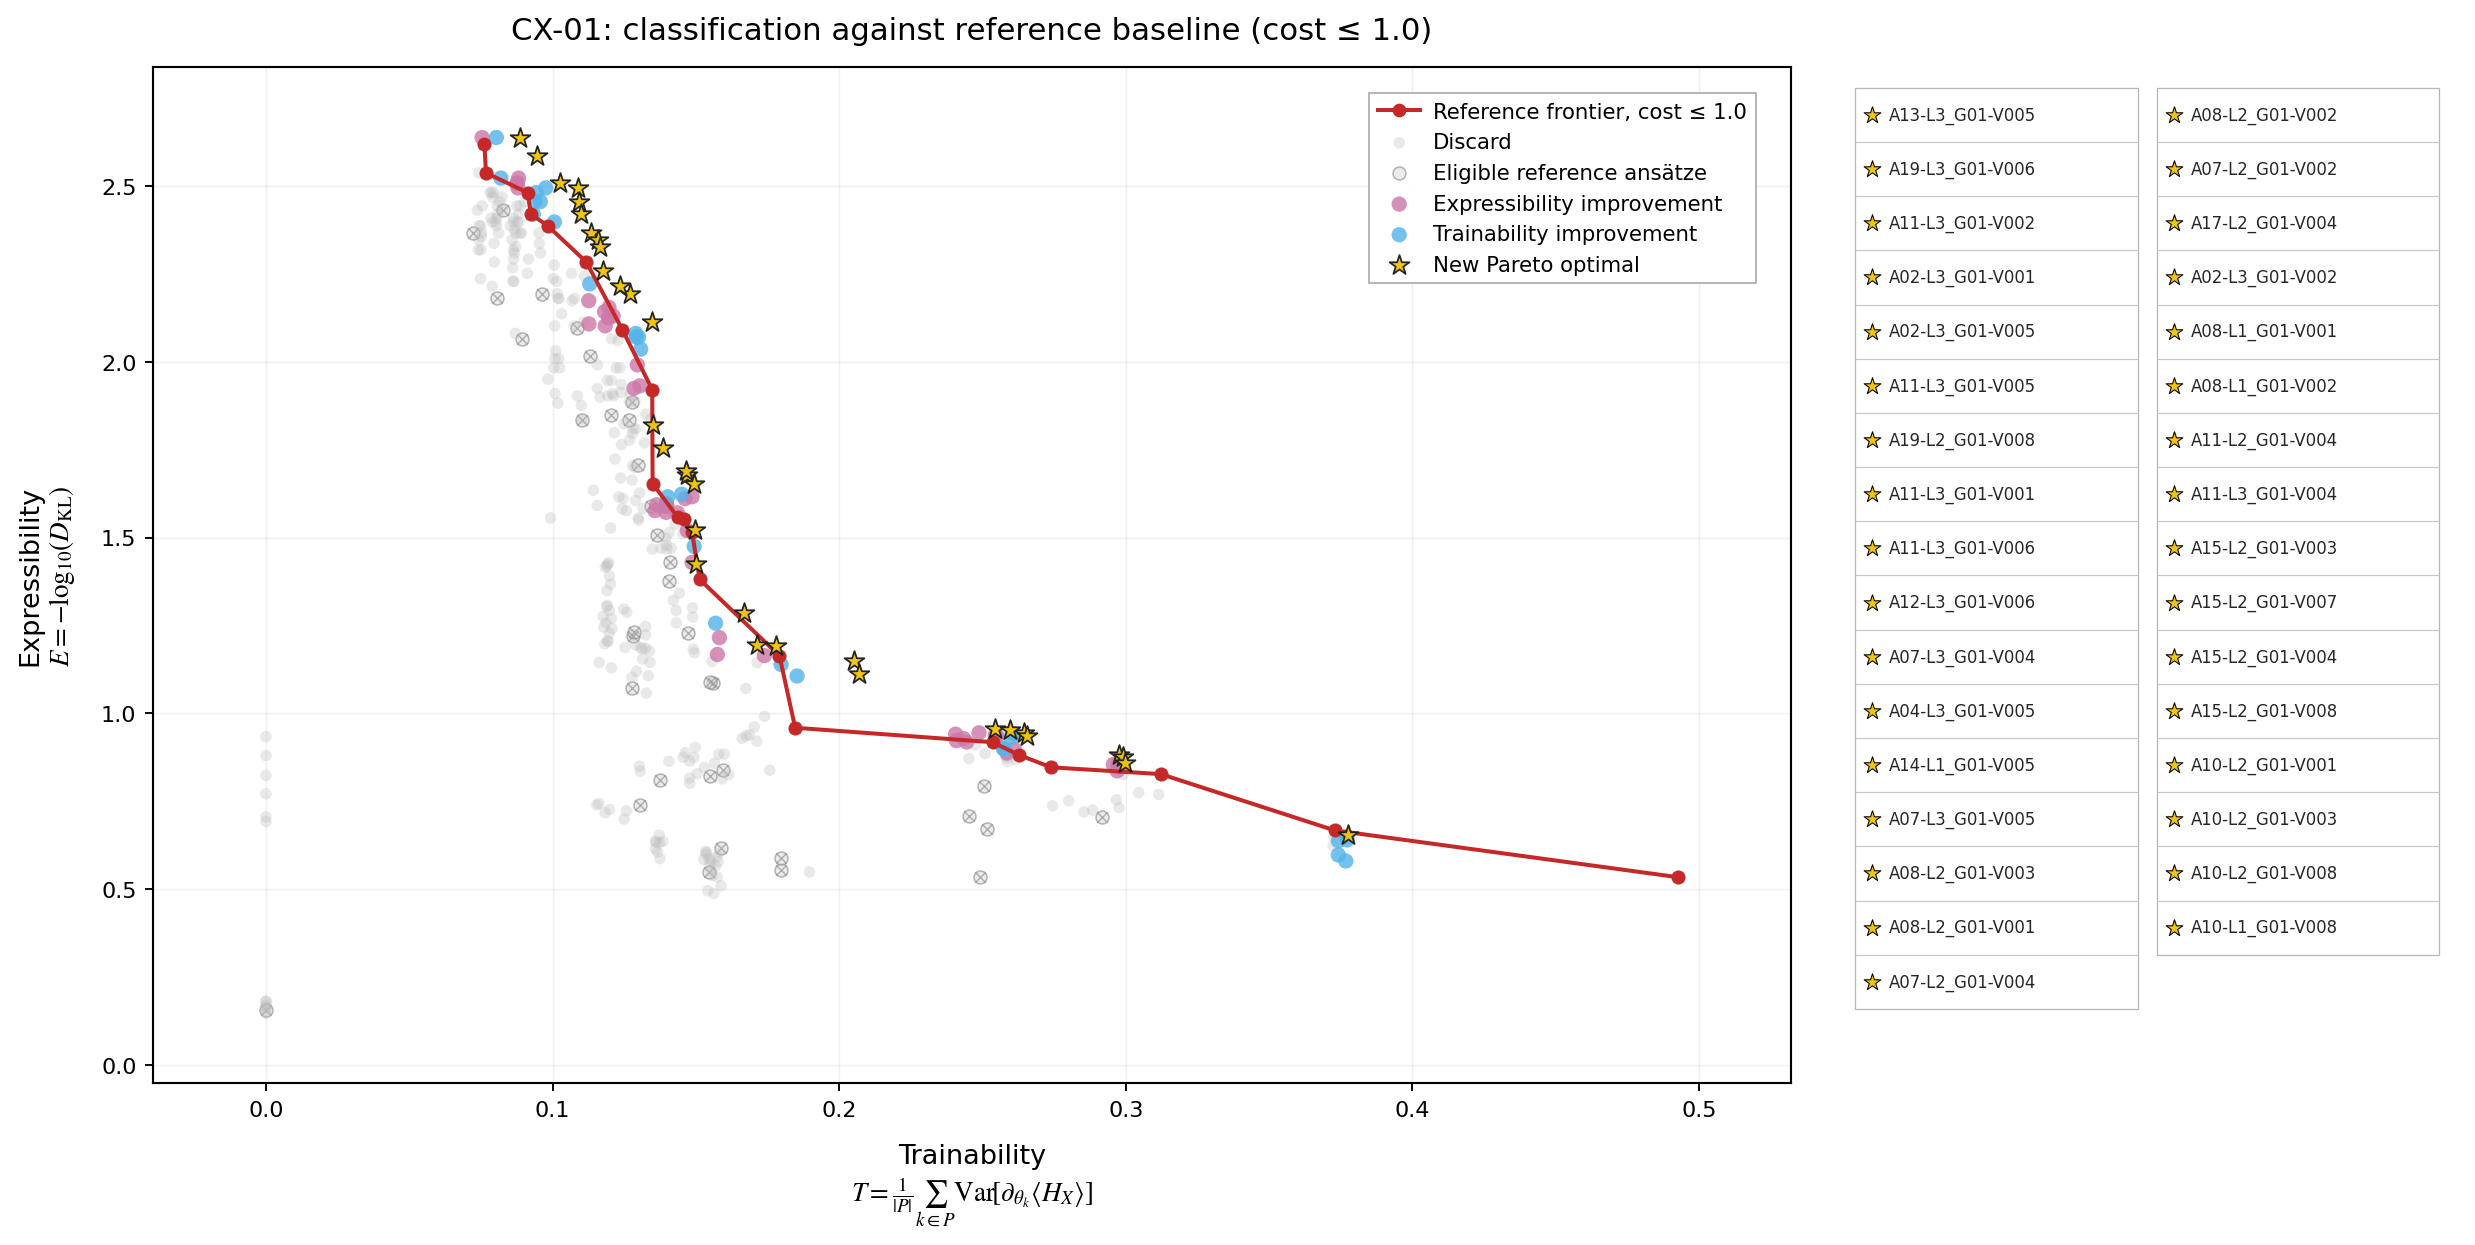

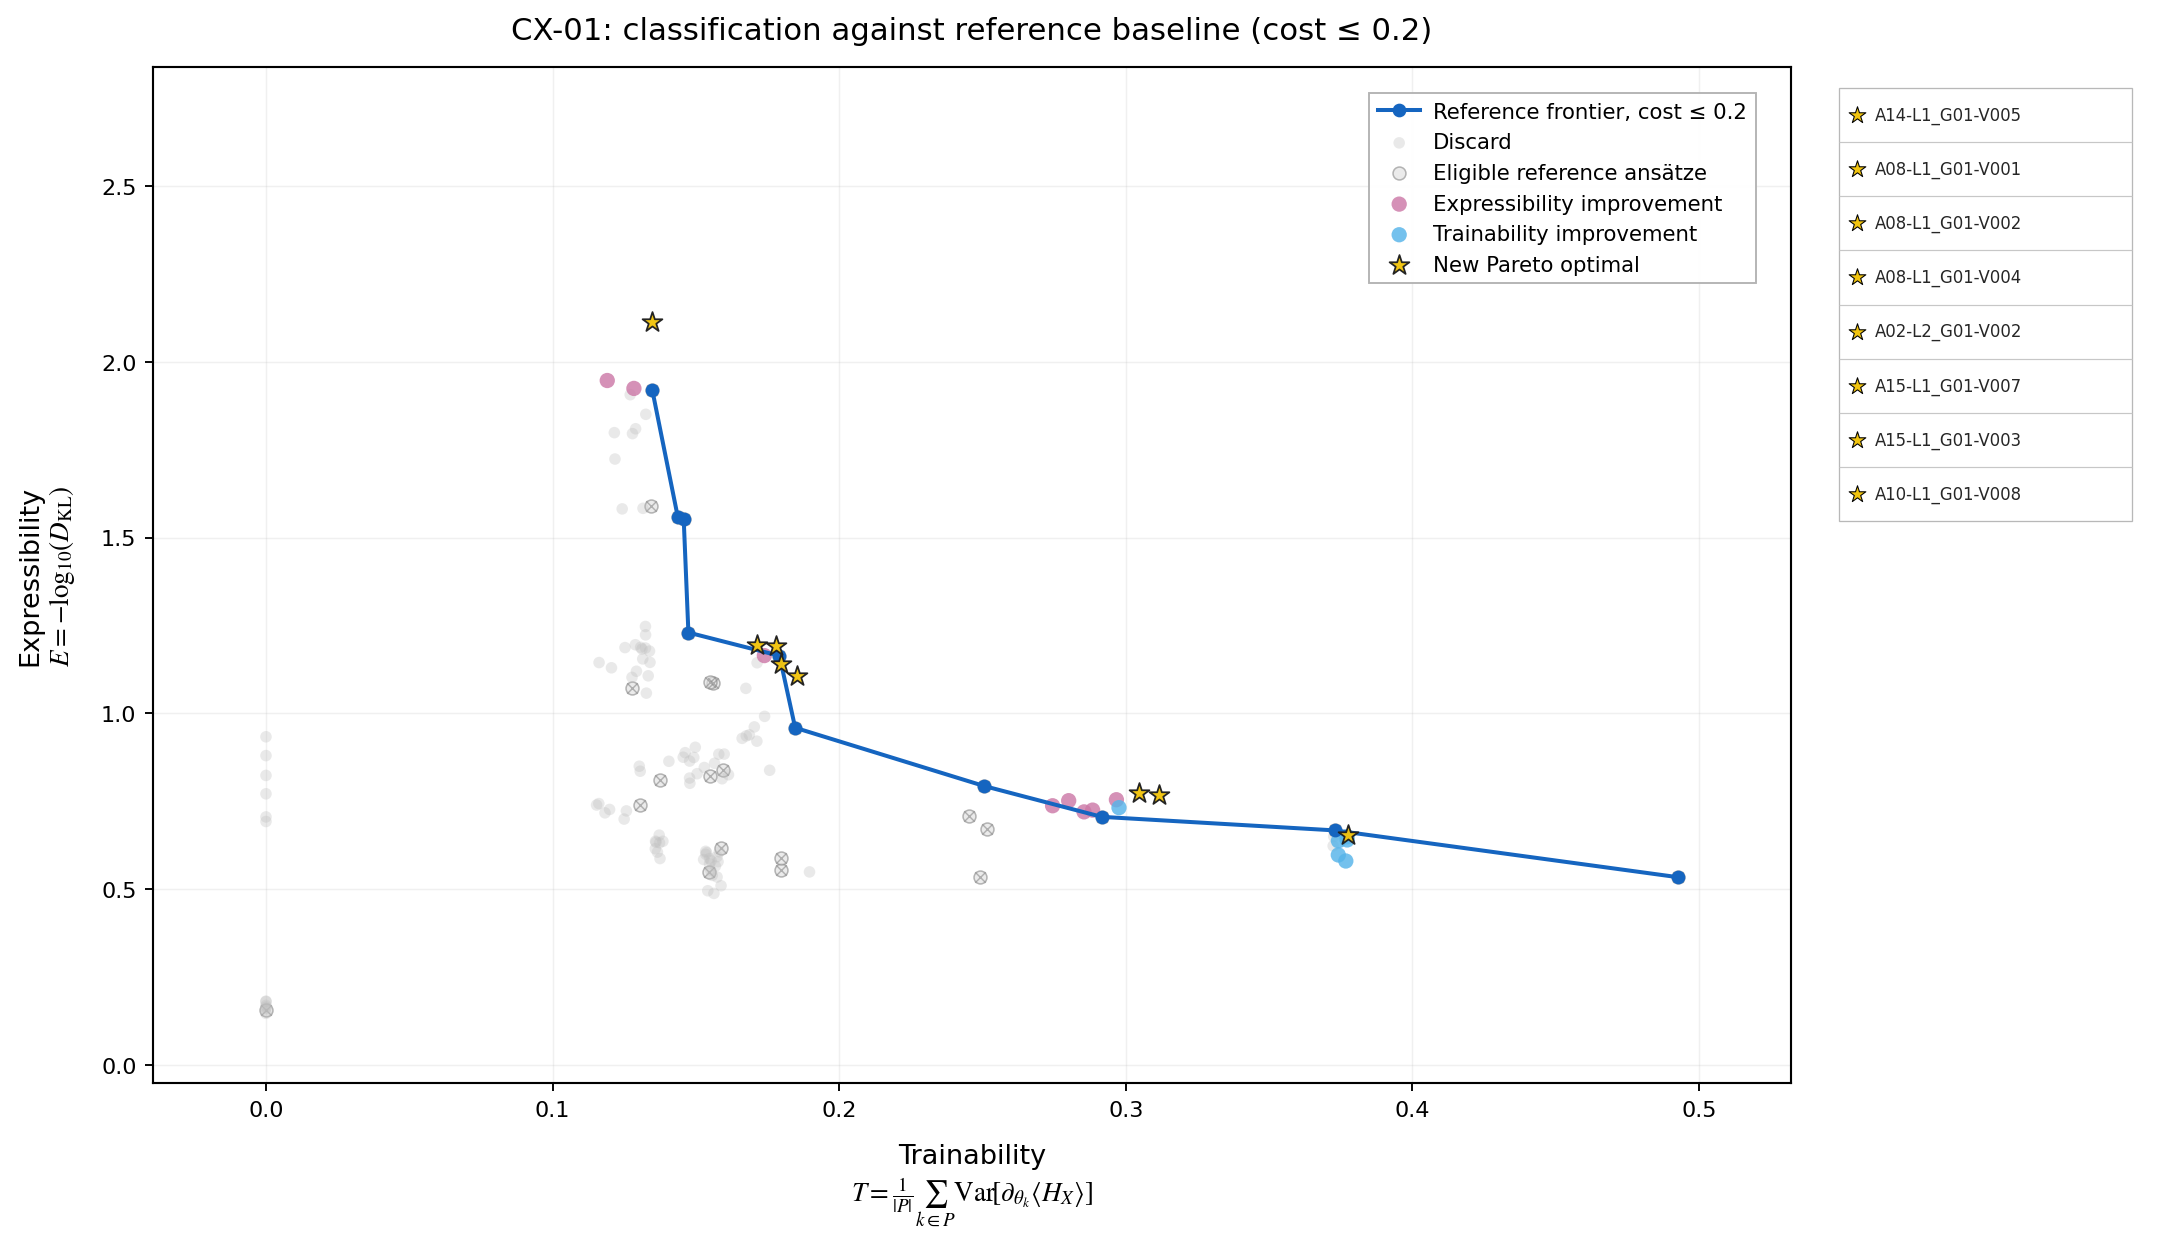

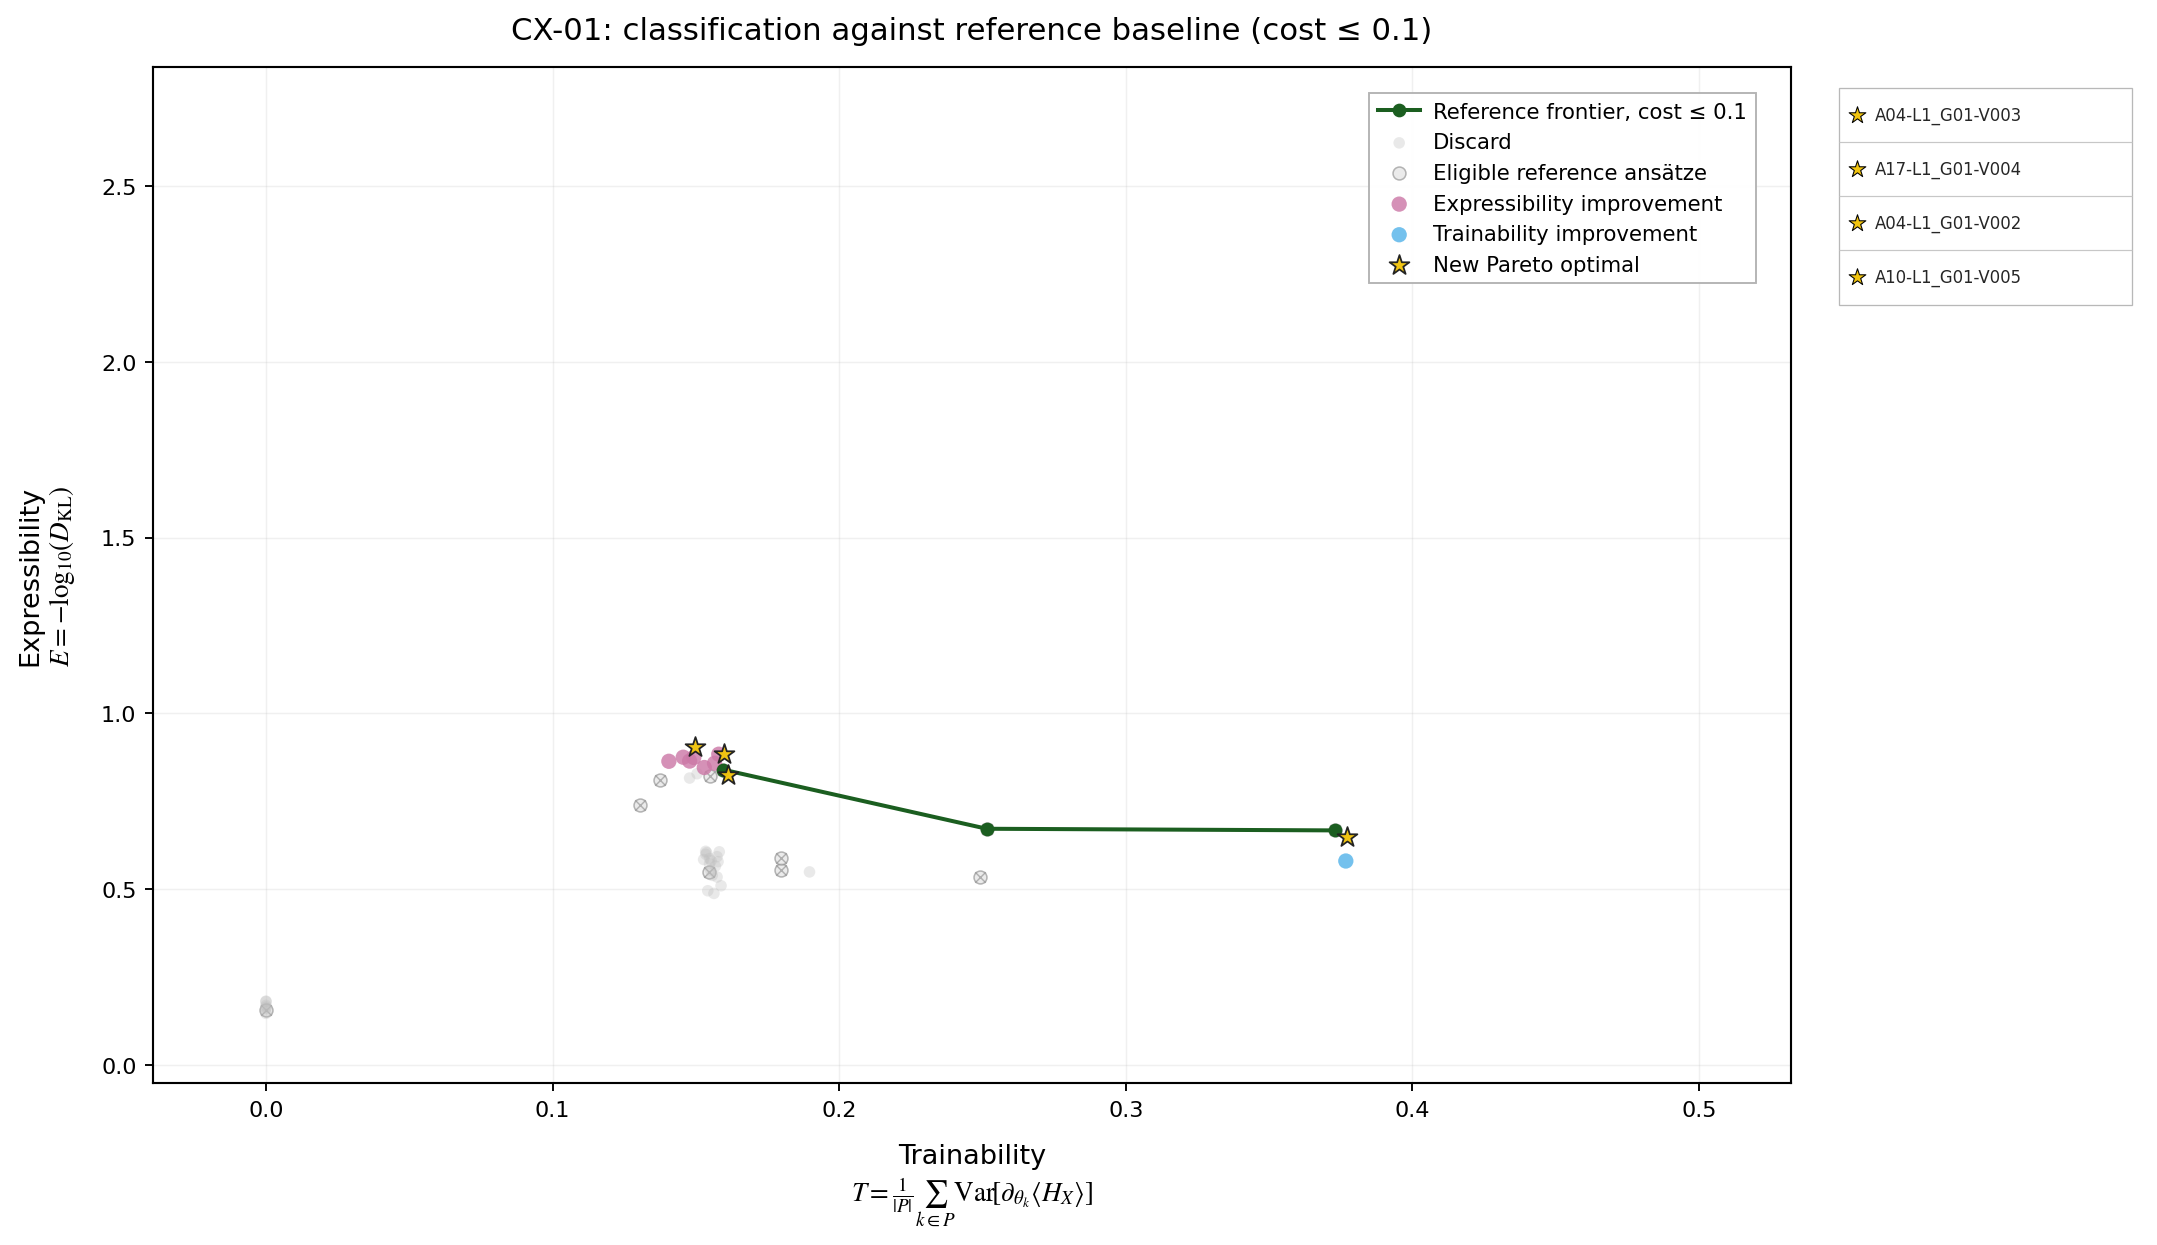

In [12]:
def plot_classification_vs_baseline(
    classified: pd.DataFrame,
    baseline_frontier: pd.DataFrame,
    threshold: float,
) -> None:
    label = threshold_label(threshold)

    baseline_eligible = sanz_reference.loc[
        sanz_reference["cost_norm_reference"] <= threshold + NUMERICAL_TOLERANCE
    ].copy()
    eligible_candidates = classified.loc[classified["passes_cost"]].copy()

    new_pareto = eligible_candidates.loc[
        eligible_candidates["plot_category"] == "new_pareto"
    ].copy()
    new_pareto["plot_circuit_id"] = new_pareto["circuit_id"].map(format_plot_circuit_id)
    panel_entries = (
        new_pareto.sort_values(
            ["expressibility_score", "trainability_score"],
            ascending=[False, True],
        )[["plot_circuit_id"]]
        .rename(columns={"plot_circuit_id": "label"})
        .to_dict("records")
    )

    base_plot_width = 10.8
    panel_col_width = TABLE_PANEL_REFERENCE_COL_WIDTH
    max_rows = TABLE_PANEL_REFERENCE_MAX_ROWS
    n_panel_cols = max(1, int(np.ceil(max(len(panel_entries), 1) / max_rows)))
    fig_width = base_plot_width + panel_col_width * n_panel_cols
    fig = plt.figure(figsize=(fig_width, 7.2))

    left = 0.07
    bottom = 0.11
    height = 0.83
    gap = 0.018
    right = 0.02
    usable_width = 1.0 - left - right - gap
    plot_fraction = base_plot_width / fig_width
    panel_fraction = (panel_col_width * n_panel_cols) / fig_width
    plot_width = usable_width * plot_fraction / (plot_fraction + panel_fraction)
    panel_width = usable_width - plot_width

    ax = fig.add_axes([left, bottom, plot_width, height])
    panel_ax = fig.add_axes([left + plot_width + gap, bottom, panel_width, height])

    eligible_handle = ax.scatter(
        baseline_eligible["trainability_score"],
        baseline_eligible["expressibility_score"],
        marker="o",
        s=30,
        facecolors="#E0E0E0",
        edgecolors="#8A8A8A",
        linewidths=0.65,
        alpha=0.62,
        zorder=1,
        label="Eligible reference ansätze",
    )
    ax.scatter(
        baseline_eligible["trainability_score"],
        baseline_eligible["expressibility_score"],
        marker="x",
        s=20,
        color="#8A8A8A",
        linewidths=0.60,
        alpha=0.62,
        zorder=2,
    )

    frontier = sorted_frontier(baseline_frontier)
    frontier_color = FRONTIER_COLORS[threshold]
    frontier_handle, = ax.plot(
        frontier["trainability_score"],
        frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=4.8,
        color=frontier_color,
        linewidth=1.7,
        zorder=7,
        label=f"Reference frontier, cost ≤ {threshold}",
    )

    category_handles: dict[str, Any] = {}
    for category in PLOT_CATEGORY_ORDER:
        subset = eligible_candidates.loc[eligible_candidates["plot_category"] == category]
        if subset.empty:
            continue
        marker = PLOT_CATEGORY_MARKERS[category]
        is_new_pareto = category == "new_pareto"
        is_discard = category == "discard"
        category_handles[category] = ax.scatter(
            subset["trainability_score"],
            subset["expressibility_score"],
            marker=marker,
            s=PLOT_CATEGORY_SIZES[category],
            color=PLOT_CATEGORY_COLORS[category],
            alpha=PLOT_CATEGORY_ALPHAS[category],
            edgecolors="#202020" if is_new_pareto else ("none" if is_discard else "none"),
            linewidths=0.75 if is_new_pareto else 0.0,
            zorder=PLOT_CATEGORY_ZORDERS[category],
            label=PLOT_CATEGORY_LABELS[category],
        )

    ax.set_xlim(*COMMON_X_LIMITS)
    ax.set_ylim(*COMMON_Y_LIMITS)
    ax.set_xlabel(TRAINABILITY_AXIS_LABEL, labelpad=10)
    ax.set_ylabel(EXPRESSIBILITY_AXIS_LABEL, labelpad=10)
    ax.set_title(
        f"{CAMPAIGN_ID}: classification against reference baseline (cost ≤ {threshold})",
        pad=12,
    )
    ax.grid(alpha=0.18)

    legend_handles = [
        frontier_handle,
        category_handles.get("discard"),
        eligible_handle,
        category_handles.get("expressibility_gain"),
        category_handles.get("trainability_gain"),
        category_handles.get("new_pareto"),
    ]
    legend_labels = [
        f"Reference frontier, cost ≤ {threshold}",
        PLOT_CATEGORY_LABELS["discard"],
        "Eligible reference ansätze",
        PLOT_CATEGORY_LABELS["expressibility_gain"],
        PLOT_CATEGORY_LABELS["trainability_gain"],
        PLOT_CATEGORY_LABELS["new_pareto"],
    ]
    legend_pairs = [(h, l) for h, l in zip(legend_handles, legend_labels) if h is not None]
    ax.legend(
        [h for h, _ in legend_pairs],
        [l for _, l in legend_pairs],
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor="#B0B0B0",
        ncols=1,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        columnspacing=1.2,
        handletextpad=0.6,
    )

    draw_tabulated_label_panel(
        panel_ax,
        panel_entries,
        label_key="label",
        mode="star",
        max_rows=max_rows,
        star_color=PLOT_CATEGORY_COLORS["new_pareto"],
        text_fontsize=TABLE_PANEL_REFERENCE_TEXT_FONTSIZE,
    )

    eligible_candidates.to_csv(
        PLOT_DATA_DIR / f"C1_classification_cost_{label}.csv",
        index=False,
    )
    finalize_figure(fig, f"C1_classification_vs_baseline_cost_{label}")


for threshold in COST_THRESHOLDS:
    plot_classification_vs_baseline(
        classifications[threshold],
        baseline_frontiers[threshold],
        threshold,
    )


## 12. C2 — The three new joint Pareto frontiers with circuit labels


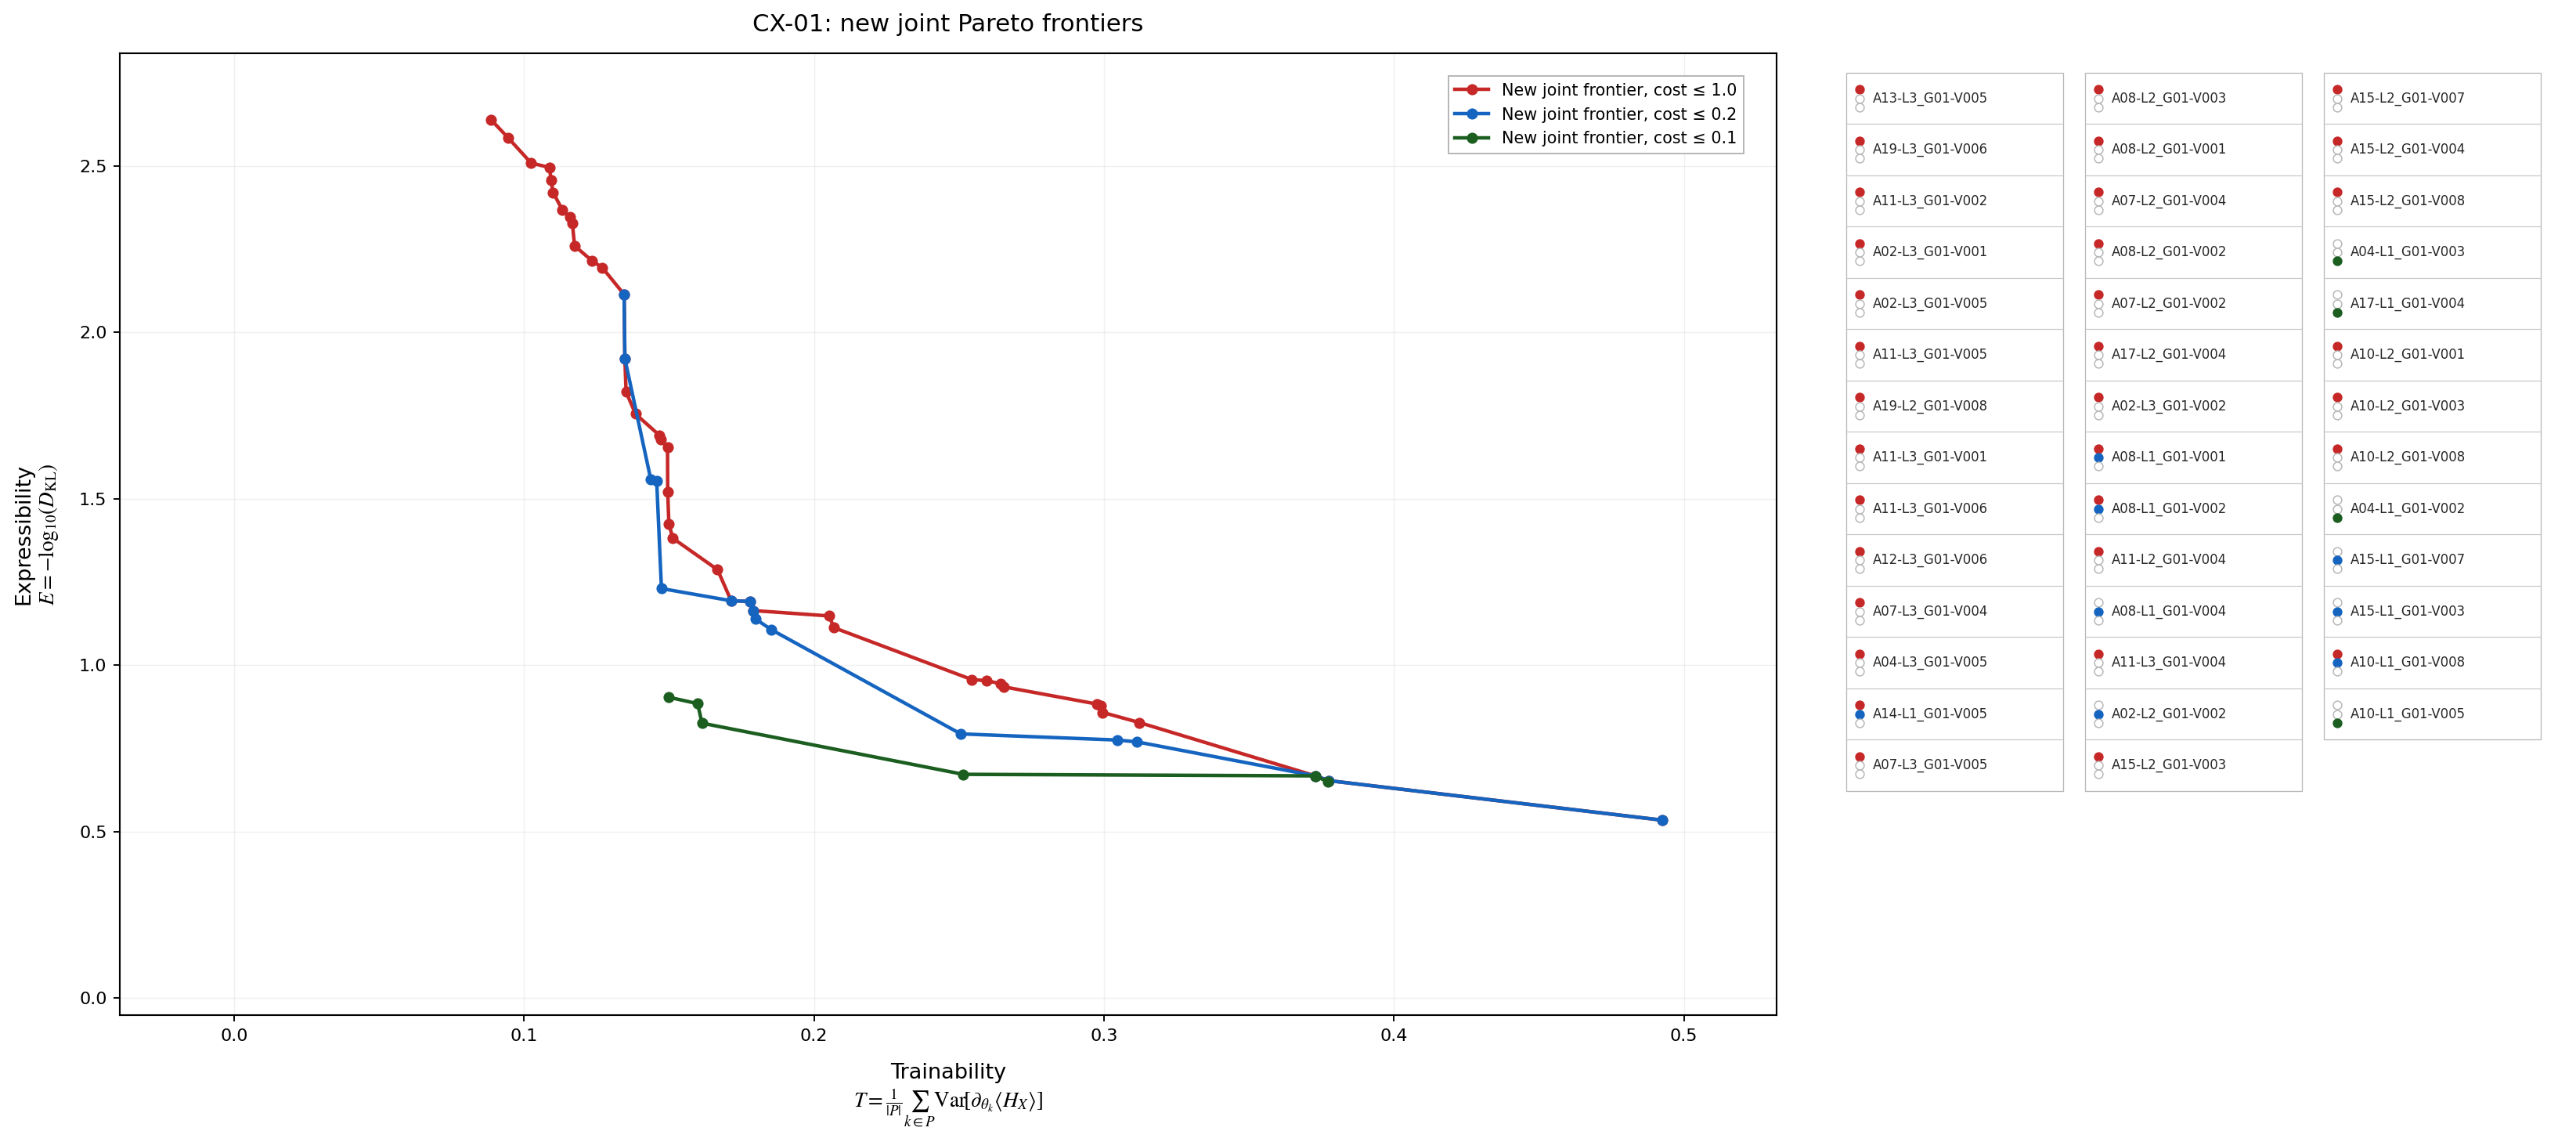

In [13]:
unique_new_rows: dict[str, dict[str, Any]] = {}

for threshold in COST_THRESHOLDS:
    frontier = sorted_frontier(joint_frontiers[threshold])
    new_members = frontier.loc[frontier["frontier_source"] == "candidate"].copy()
    for _, row in new_members.iterrows():
        circuit_id = str(row["circuit_id"])
        entry = unique_new_rows.setdefault(
            circuit_id,
            {
                "circuit_id": circuit_id,
                "plot_circuit_id": format_plot_circuit_id(circuit_id),
                "trainability_score": float(row["trainability_score"]),
                "expressibility_score": float(row["expressibility_score"]),
                "thresholds": [],
            },
        )
        entry["thresholds"].append(float(threshold))

labels_frame = pd.DataFrame(unique_new_rows.values())
panel_entries = []
if not labels_frame.empty:
    panel_entries = (
        labels_frame.sort_values(
            ["expressibility_score", "trainability_score"],
            ascending=[False, True],
        )[["plot_circuit_id", "thresholds"]]
        .rename(columns={"plot_circuit_id": "label"})
        .to_dict("records")
    )

base_plot_width = 13.8
panel_col_width = TABLE_PANEL_REFERENCE_COL_WIDTH
max_rows = TABLE_PANEL_REFERENCE_MAX_ROWS
n_panel_cols = max(1, int(np.ceil(max(len(panel_entries), 1) / max_rows)))
fig_width = base_plot_width + panel_col_width * n_panel_cols
fig = plt.figure(figsize=(fig_width, 8.6))

left = 0.06
bottom = 0.10
height = 0.84
gap = 0.018
right = 0.02
usable_width = 1.0 - left - right - gap
plot_fraction = base_plot_width / fig_width
panel_fraction = (panel_col_width * n_panel_cols) / fig_width
plot_width = usable_width * plot_fraction / (plot_fraction + panel_fraction)
panel_width = usable_width - plot_width

ax = fig.add_axes([left, bottom, plot_width, height])
panel_ax = fig.add_axes([left + plot_width + gap, bottom, panel_width, height])

for threshold in COST_THRESHOLDS:
    frontier = sorted_frontier(joint_frontiers[threshold])
    color = FRONTIER_COLORS[threshold]
    ax.plot(
        frontier["trainability_score"],
        frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=5.0,
        color=color,
        linewidth=1.9,
        zorder=6,
        label=f"New joint frontier, cost ≤ {threshold}",
    )

ax.set_xlim(*COMMON_X_LIMITS)
ax.set_ylim(*COMMON_Y_LIMITS)
ax.set_xlabel(TRAINABILITY_AXIS_LABEL, labelpad=10)
ax.set_ylabel(EXPRESSIBILITY_AXIS_LABEL, labelpad=10)
ax.set_title(f"{CAMPAIGN_ID}: new joint Pareto frontiers", pad=12)
ax.grid(alpha=0.18)

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="#B0B0B0",
)
for text in legend.get_texts():
    text.set_fontsize(8.8)

draw_tabulated_label_panel(
    panel_ax,
    panel_entries,
    label_key="label",
    mode="semaphore",
    max_rows=max_rows,
    frontier_colors=FRONTIER_COLORS,
    thresholds_key="thresholds",
    text_fontsize=TABLE_PANEL_REFERENCE_TEXT_FONTSIZE,
)

pd.concat(
    [
        frontier.assign(cost_threshold=threshold)
        for threshold, frontier in joint_frontiers.items()
    ],
    ignore_index=True,
).to_csv(
    PLOT_DATA_DIR / "C2_joint_frontiers_all_costs.csv",
    index=False,
)

finalize_figure(fig, "C2_joint_frontiers_all_costs")


## 13. C3 — Baseline frontiers versus new joint frontiers


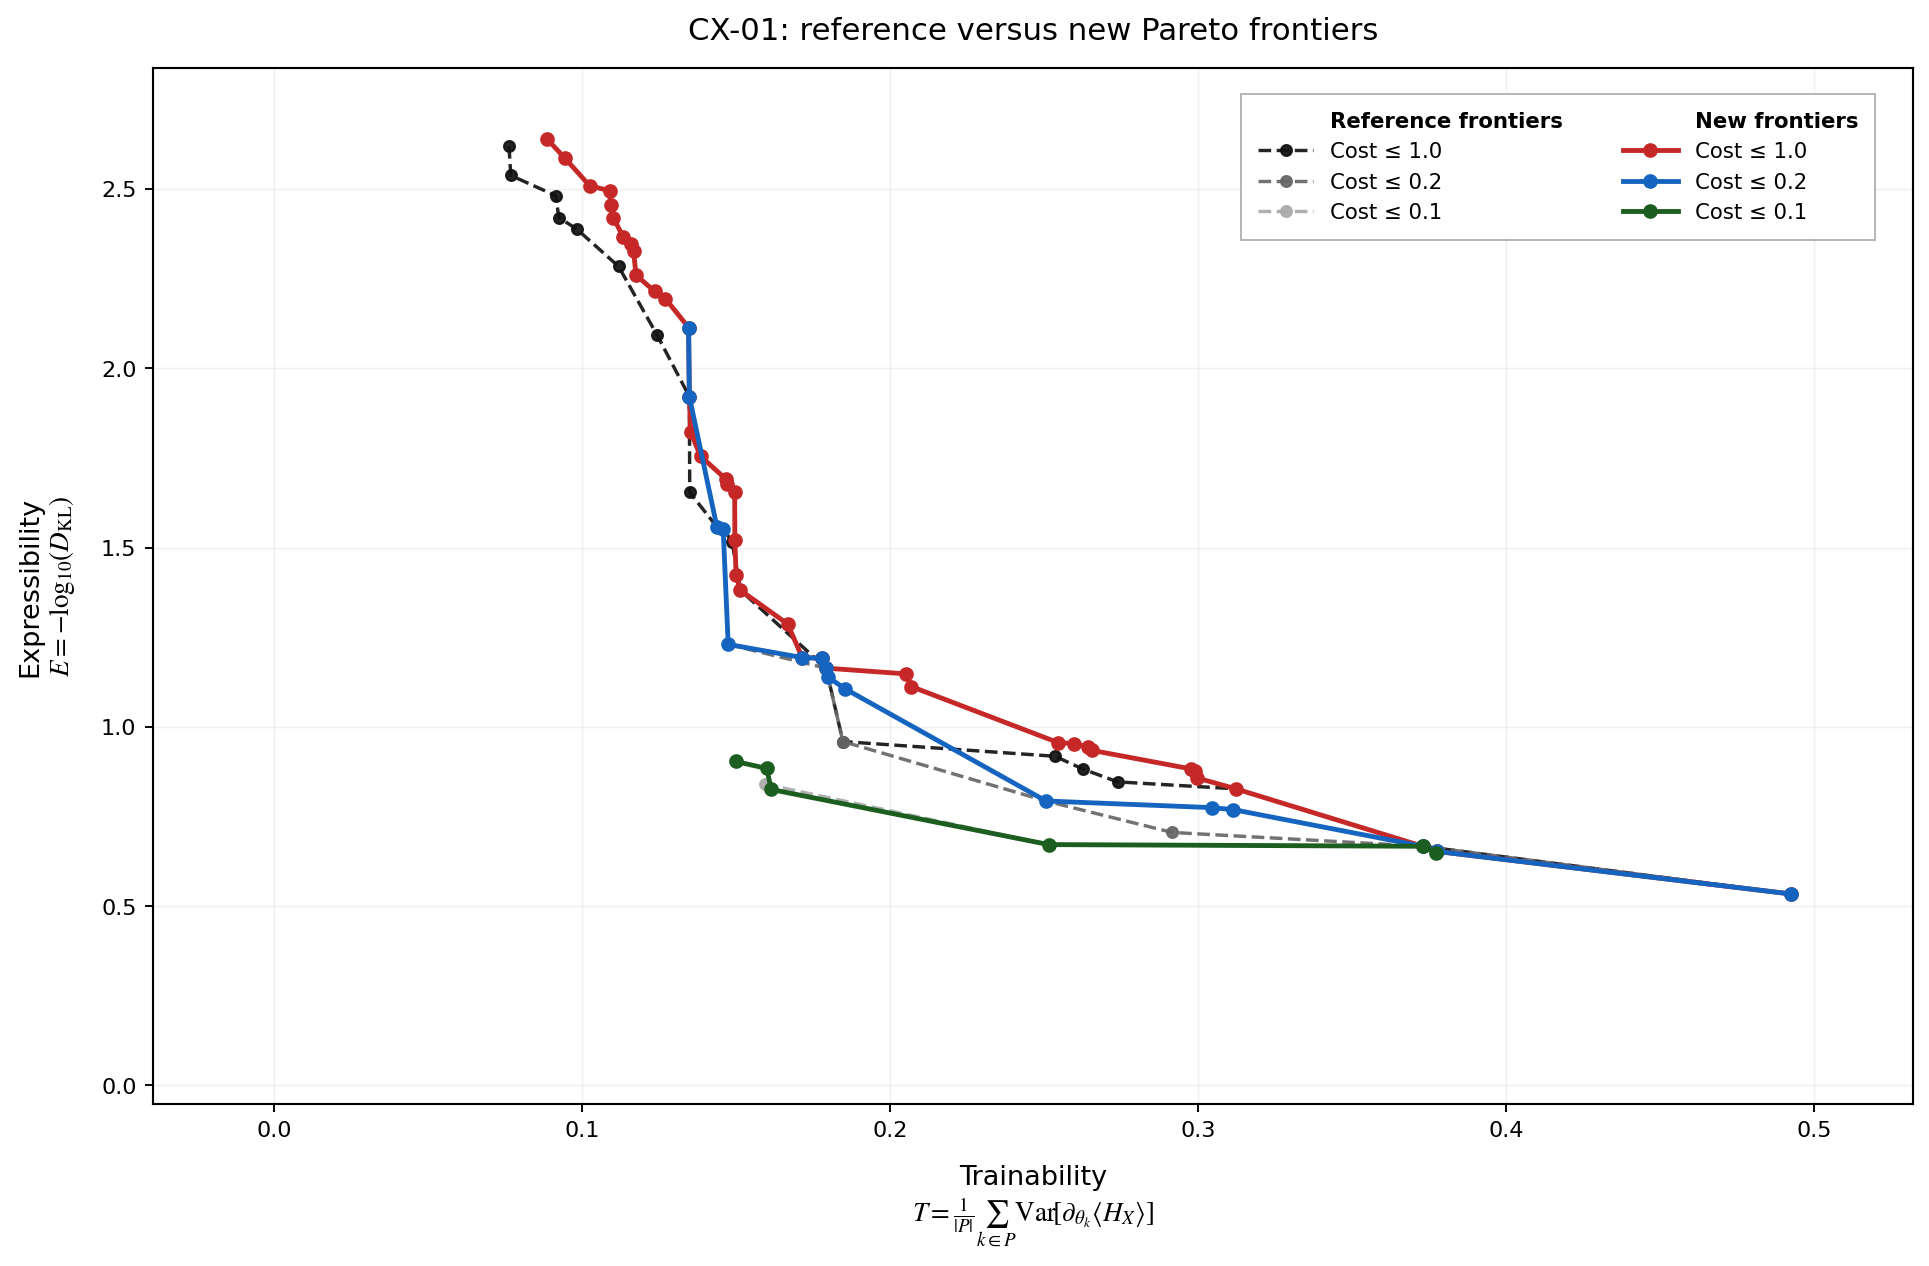

In [14]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11.5, 7.6))

comparison_rows: list[pd.DataFrame] = []
reference_handles = []
new_frontier_handles = []

for threshold in COST_THRESHOLDS:
    baseline_frontier = sorted_frontier(
        baseline_frontiers[threshold]
    )
    joint_frontier = sorted_frontier(
        joint_frontiers[threshold]
    )

    reference_line, = ax.plot(
        baseline_frontier["trainability_score"],
        baseline_frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=4.5,
        color=REFERENCE_FRONTIER_COLORS[threshold],
        linewidth=1.45,
        linestyle="--",
        alpha=0.92,
        antialiased=True,
        zorder=4,
        label=f"Cost ≤ {threshold}",
    )
    new_line, = ax.plot(
        joint_frontier["trainability_score"],
        joint_frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=5.2,
        color=FRONTIER_COLORS[threshold],
        linewidth=2.05,
        linestyle="-",
        antialiased=True,
        zorder=7,
        label=f"Cost ≤ {threshold}",
    )

    reference_handles.append(reference_line)
    new_frontier_handles.append(new_line)

    comparison_rows.extend(
        [
            baseline_frontier.assign(
                frontier_type="baseline",
                cost_threshold=threshold,
            ),
            joint_frontier.assign(
                frontier_type="joint",
                cost_threshold=threshold,
            ),
        ]
    )

ax.set_xlim(*COMMON_X_LIMITS)
ax.set_ylim(*COMMON_Y_LIMITS)
ax.set_xlabel(TRAINABILITY_AXIS_LABEL, labelpad=10)
ax.set_ylabel(EXPRESSIBILITY_AXIS_LABEL, labelpad=10)
ax.set_title(
    f"{CAMPAIGN_ID}: reference versus new Pareto frontiers",
    pad=12,
)
ax.grid(alpha=0.18)

header_reference = Line2D(
    [], [], linestyle="none", marker="", label="Reference frontiers"
)
header_new = Line2D(
    [], [], linestyle="none", marker="", label="New frontiers"
)

legend_handles = (
    [header_reference]
    + reference_handles
    + [header_new]
    + new_frontier_handles
)
legend_labels = (
    ["Reference frontiers"]
    + [f"Cost ≤ {value}" for value in COST_THRESHOLDS]
    + ["New frontiers"]
    + [f"Cost ≤ {value}" for value in COST_THRESHOLDS]
)

frontier_legend = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    ncols=2,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="#B0B0B0",
    borderpad=0.8,
    handlelength=2.6,
    columnspacing=2.8,
    handletextpad=0.8,
)

legend_texts = frontier_legend.get_texts()
if len(legend_texts) >= 5:
    legend_texts[0].set_weight("bold")
    legend_texts[4].set_weight("bold")

fig.tight_layout(pad=1.2)

pd.concat(comparison_rows, ignore_index=True).to_csv(
    PLOT_DATA_DIR / "C3_baseline_vs_joint_frontiers.csv",
    index=False,
)

finalize_figure(fig, "C3_baseline_vs_joint_frontiers")


## 14. C4 — Original frontiers with campaign circuits grouped by layer


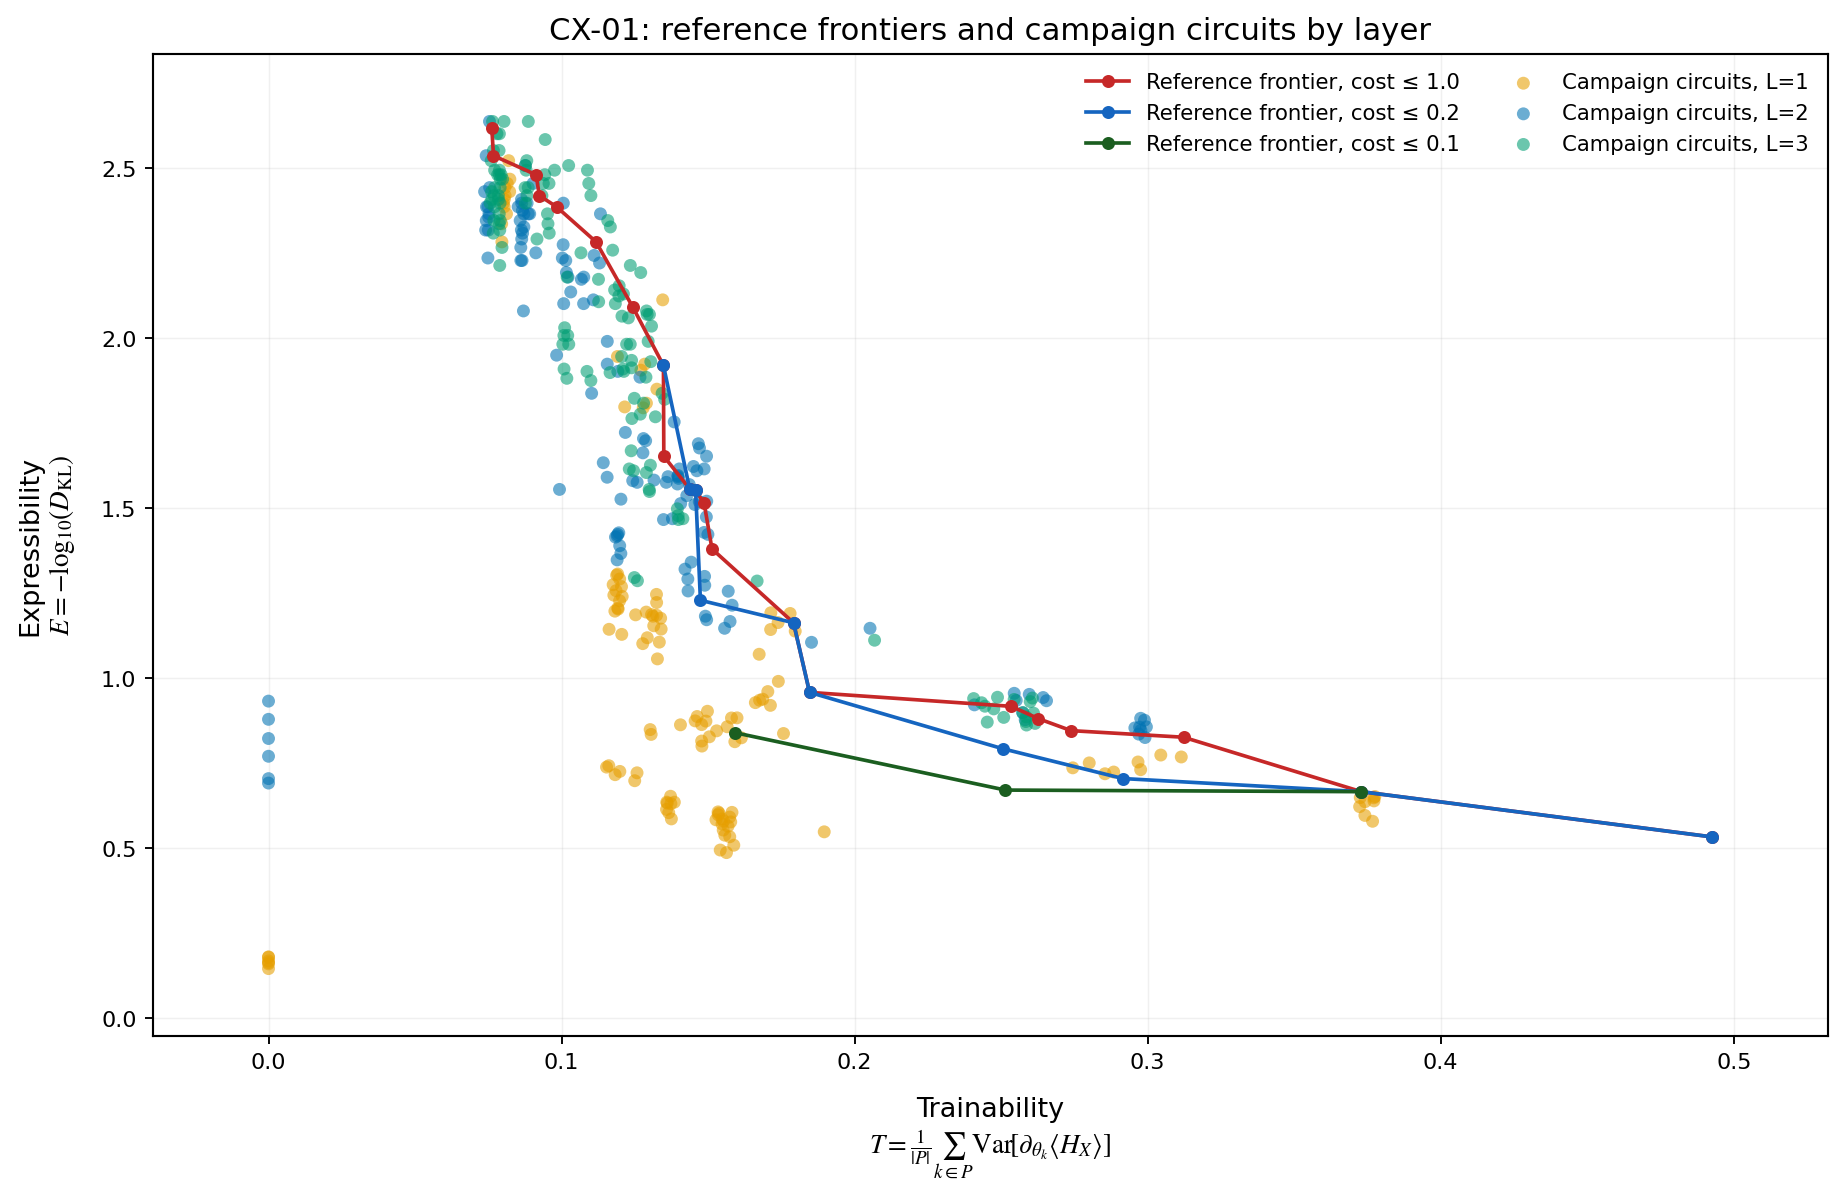

In [15]:
fig, ax = plt.subplots(figsize=(11.0, 7.2))

for threshold in COST_THRESHOLDS:
    frontier = sorted_frontier(baseline_frontiers[threshold])
    ax.plot(
        frontier["trainability_score"],
        frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=4.5,
        color=FRONTIER_COLORS[threshold],
        linewidth=1.55,
        zorder=7,
        label=f"Reference frontier, cost ≤ {threshold}",
    )

for layer in sorted(campaign["L"].unique()):
    subset = campaign.loc[campaign["L"] == layer]
    ax.scatter(
        subset["trainability_score"],
        subset["expressibility_score"],
        marker=POINT_MARKER,
        s=30,
        color=LAYER_COLORS[int(layer)],
        edgecolors="none",
        alpha=0.58,
        zorder=3,
        label=f"Campaign circuits, L={layer}",
    )

ax.set_xlim(*COMMON_X_LIMITS)
ax.set_ylim(*COMMON_Y_LIMITS)
ax.set_xlabel(TRAINABILITY_AXIS_LABEL, labelpad=10)
ax.set_ylabel(EXPRESSIBILITY_AXIS_LABEL, labelpad=10)
ax.set_title(
    f"{CAMPAIGN_ID}: reference frontiers and campaign circuits by layer"
)
ax.grid(alpha=0.18)
ax.legend(frameon=False, ncols=2)
fig.tight_layout(pad=1.2)

campaign[
    [
        "circuit_id",
        "L",
        "expressibility_score",
        "trainability_score",
        "combined_score",
        "cost_norm_reference",
    ]
].to_csv(
    PLOT_DATA_DIR / "C4_campaign_circuits_by_layer.csv",
    index=False,
)

finalize_figure(fig, "C4_reference_frontiers_campaign_by_layer")


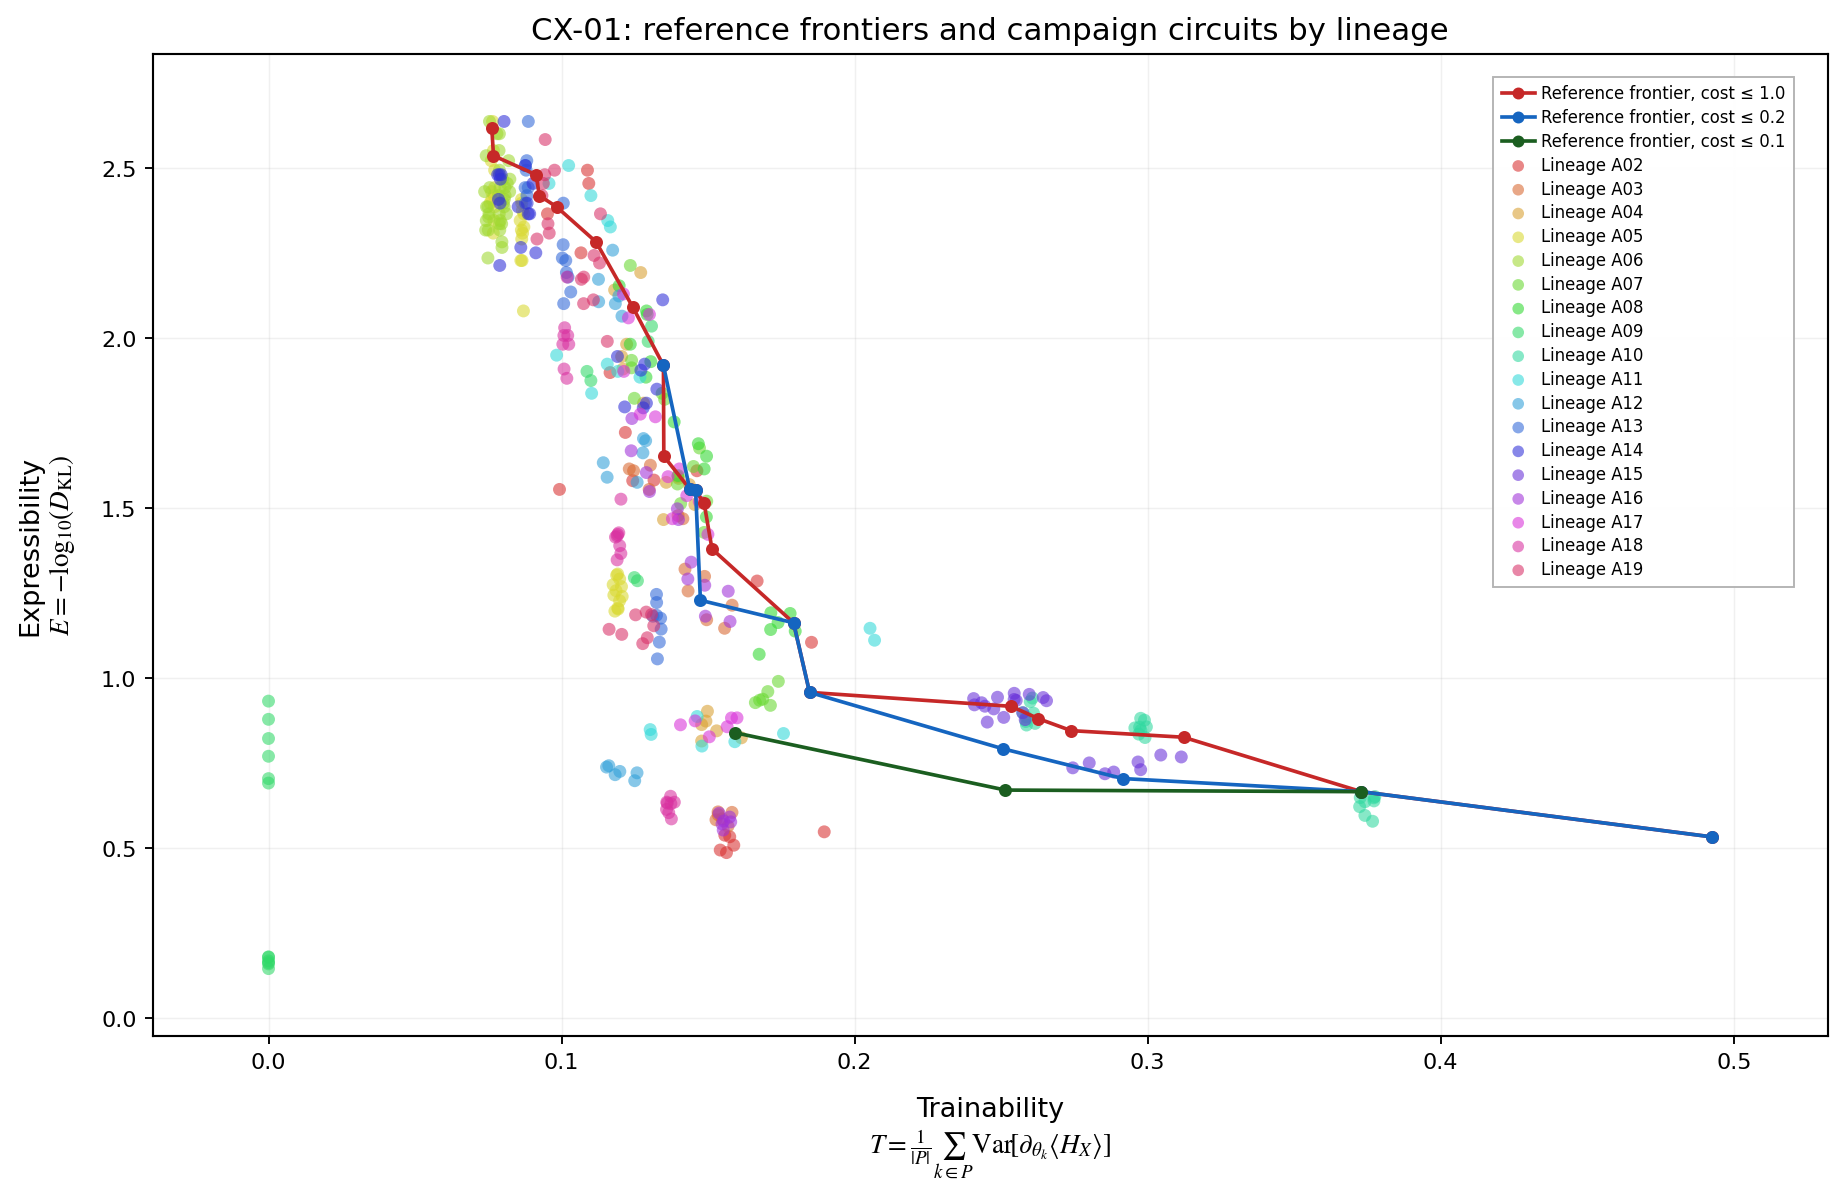

In [16]:
# C5. Reference frontiers against campaign circuits grouped by lineage.
lineage_table = campaign.copy()
lineage_table["lineage_id"] = lineage_table["template_id"].astype(str)
lineage_ids = sorted(lineage_table["lineage_id"].unique())

lineage_color_map: dict[str, Any] = {}
if lineage_ids:
    hue_values = np.linspace(0.0, 1.0, len(lineage_ids), endpoint=False)
    for lineage_id, hue in zip(lineage_ids, hue_values):
        lineage_color_map[lineage_id] = matplotlib.colors.hsv_to_rgb((hue, 0.78, 0.85))

fig, ax = plt.subplots(figsize=(11.0, 7.2))

for threshold in COST_THRESHOLDS:
    frontier = sorted_frontier(baseline_frontiers[threshold])
    ax.plot(
        frontier["trainability_score"],
        frontier["expressibility_score"],
        marker=POINT_MARKER,
        markersize=4.5,
        color=FRONTIER_COLORS[threshold],
        linewidth=1.55,
        zorder=7,
        label=f"Reference frontier, cost ≤ {threshold}",
    )

for lineage_id in lineage_ids:
    subset = lineage_table.loc[lineage_table["lineage_id"] == lineage_id].copy()
    ax.scatter(
        subset["trainability_score"],
        subset["expressibility_score"],
        marker=POINT_MARKER,
        s=30,
        color=lineage_color_map[lineage_id],
        edgecolors="none",
        alpha=0.58,
        zorder=3,
        label=f"Lineage {lineage_id}",
    )

ax.set_xlim(*COMMON_X_LIMITS)
ax.set_ylim(*COMMON_Y_LIMITS)
ax.set_xlabel(TRAINABILITY_AXIS_LABEL, labelpad=10)
ax.set_ylabel(EXPRESSIBILITY_AXIS_LABEL, labelpad=10)
ax.set_title(
    f"{CAMPAIGN_ID}: reference frontiers and campaign circuits by lineage"
)
ax.grid(alpha=0.18)
legend = ax.legend(
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="#B0B0B0",
    ncols=1,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    fontsize=7.0,
    handletextpad=0.4,
    borderpad=0.5,
    labelspacing=0.35,
    markerscale=0.9,
)
fig.tight_layout(pad=1.2)

lineage_export = lineage_table[
    [
        "circuit_id",
        "lineage_id",
        "template_id",
        "L",
        "expressibility_score",
        "trainability_score",
        "combined_score",
        "cost_norm_reference",
    ]
].copy()
lineage_export["lineage_color"] = lineage_export["lineage_id"].map(
    lambda value: matplotlib.colors.to_hex(lineage_color_map[value])
)
lineage_export.to_csv(
    PLOT_DATA_DIR / "C5_campaign_circuits_by_lineage.csv",
    index=False,
)

finalize_figure(fig, "C5_reference_frontiers_campaign_by_lineage")


## 15. Data quality and analysis manifest

In [17]:
quality_report = pd.DataFrame(
    [
        {
            "check": "campaign_rows",
            "value": int(len(processed_campaign)),
        },
        {
            "check": "unique_campaign_circuits",
            "value": int(
                processed_campaign["circuit_id"].nunique()
            ),
        },
        {
            "check": "sanz_reference_rows",
            "value": int(len(sanz_reference)),
        },
        {
            "check": "sanz_global_pareto_rows",
            "value": int(
                sanz_reference["is_global_pareto"].sum()
            ),
        },
        {
            "check": "missing_scientific_values",
            "value": int(
                processed_campaign[
                    [
                        "dkl",
                        "expressibility_score",
                        "trainability_score",
                        "combined_score",
                    ]
                ].isna().sum().sum()
            ),
        },
        {
            "check": "missing_structural_values",
            "value": int(
                processed_campaign[
                    [
                        "parameter_count",
                        "operation_count",
                        "two_qubit_gate_count",
                        "depth",
                    ]
                ].isna().sum().sum()
            ),
        },
    ]
)

quality_report.to_csv(
    DATA_OUTPUT_DIR / "data_quality_report.csv",
    index=False,
)
display(quality_report)

manifest = {
    "analysis_version": "individual_campaign_postprocessing_v5",
    "campaign_id": CAMPAIGN_ID,
    "trainability_benchmark": {
        "hamiltonian_id": TRAINABILITY_HAMILTONIAN_ID,
        "hamiltonian_definition": TRAINABILITY_HAMILTONIAN_DEFINITION,
        "parameter_aggregation": TRAINABILITY_PARAMETER_AGGREGATION,
        "reference_context": REFERENCE_CONTEXT_LABEL,
        "scope_note": (
            "Trainability, combined score, rankings, and Pareto frontiers "
            "are specific to Local-X and are not a TFIM reproduction."
        ),
    },
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "inputs": {
        "campaign_metrics": {
            "path": str(CAMPAIGN_METRICS_CSV.resolve()),
            "sha256": sha256_file(CAMPAIGN_METRICS_CSV),
        },
        "campaign_report": {
            "path": str(CAMPAIGN_REPORT_JSON.resolve()),
            "sha256": sha256_file(CAMPAIGN_REPORT_JSON),
        },
        "sanz_reference_metrics": {
            "path": str(SANZ_REFERENCE_METRICS_CSV.resolve()),
            "sha256": sha256_file(SANZ_REFERENCE_METRICS_CSV),
        },
        "sanz_original_pareto": {
            "path": str(SANZ_ORIGINAL_PARETO_CSV.resolve()),
            "sha256": sha256_file(SANZ_ORIGINAL_PARETO_CSV),
        },
        "sanz_source": {
            "path": str(SANZ_SOURCE_PY.resolve()),
            "sha256": sha256_file(SANZ_SOURCE_PY),
        },
    },
    "definitions": {
        "expressibility_score": "-log10(dkl)",
        "trainability_score": "trainability under H = sum_i X_i",
        "combined_score": (
            "expressibility_score * trainability_score"
        ),
        "cost_norm_campaign": (
            "Sanz weighted cost using campaign min-max ranges"
        ),
        "cost_norm_reference": (
            "Sanz weighted cost using complete Sanz reference ranges"
        ),
        "baseline_frontier": (
            "Pareto frontier of Sanz circuits satisfying "
            "cost_norm_reference <= threshold"
        ),
        "joint_frontier": (
            "Pareto frontier of eligible Sanz circuits plus eligible "
            "campaign circuits"
        ),
    },
    "layer_expansion_mode": LAYER_EXPANSION_MODE,
    "cost_weights": COST_WEIGHTS,
    "cost_thresholds": list(COST_THRESHOLDS),
    "reference_ranges": reference_ranges,
    "campaign_ranges": campaign_ranges,
    "row_counts": {
        "campaign": int(len(processed_campaign)),
        "reference": int(len(sanz_reference)),
        "new_pareto_unique": int(len(pareto_optimal_table)),
    },
    "baseline_frontier_sizes": {
        str(threshold): int(len(frontier))
        for threshold, frontier in baseline_frontiers.items()
    },
    "joint_frontier_sizes": {
        str(threshold): int(len(frontier))
        for threshold, frontier in joint_frontiers.items()
    },
    "figure_formats": list(FIGURE_FORMATS),
    "figure_dpi": FIGURE_DPI,
    "python_version": sys.version,
    "library_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__,
    },
}

manifest_path = OUTPUT_DIR / "analysis_manifest.json"
with manifest_path.open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, ensure_ascii=False)

print(f"Manifest: {manifest_path.resolve()}")
print("Individual campaign postprocessing completed successfully.")


,check,value
0,campaign_rows,396
1,unique_campaign_circuits,396
2,sanz_reference_rows,57
3,sanz_global_pareto_rows,21
4,missing_scientific_values,0
5,missing_structural_values,0


Manifest: /mnt/data/postprocessing_outputs_v5/CX-01/analysis_manifest.json
Individual campaign postprocessing completed successfully.


In [18]:
# Final v3 contract checks.
assert TRAINABILITY_HAMILTONIAN_ID == "local_x"
assert TRAINABILITY_HAMILTONIAN_DEFINITION == "sum_i X_i"
assert set(COST_THRESHOLDS) == {1.0, 0.2, 0.1}

for threshold in COST_THRESHOLDS:
    assert threshold in baseline_frontiers
    assert threshold in joint_frontiers
    assert threshold in classifications

assert len(processed_campaign) == len(campaign_metrics_raw)
assert processed_campaign["trainability_score"].notna().all()
assert processed_campaign["expressibility_score"].notna().all()

print("v3 validation completed successfully.")
print(
    "Plot convention: horizontal=trainability, "
    "vertical=expressibility."
)
print(
    "Benchmark: Local-X, H = sum_i X_i."
)


v3 validation completed successfully.
Plot convention: horizontal=trainability, vertical=expressibility.
Benchmark: Local-X, H = sum_i X_i.


In [19]:
# v5 visualization and rendering contract checks.
assert FIGURE_DPI == 600
assert "\n" in TRAINABILITY_AXIS_LABEL
assert "\n" in EXPRESSIBILITY_AXIS_LABEL
assert r"\frac{1}{|P|}" in TRAINABILITY_AXIS_LABEL
assert r"-\log_{10}" in EXPRESSIBILITY_AXIS_LABEL
assert FRONTIER_COLORS == {
    1.0: "#C62828",
    0.2: "#1565C0",
    0.1: "#1B5E20",
}
assert LAYER_COLORS == {
    1: "#E69F00",
    2: "#0072B2",
    3: "#009E73",
}
assert TABLE_PANEL_REFERENCE_MAX_ROWS == 18
assert TABLE_PANEL_REFERENCE_COL_WIDTH == 2.05
assert TABLE_PANEL_REFERENCE_TEXT_FONTSIZE == 7.0
assert PLOT_CATEGORY_LABELS["discard"] == "Discard"
assert format_plot_circuit_id("SANZ19-A10-L1") == "A10-L1"

for threshold, classified in classifications.items():
    plotted_rows = classified.loc[classified["passes_cost"]]
    assert (plotted_rows["cost_norm_reference"] <= threshold + NUMERICAL_TOLERANCE).all()

print("v5 contract validated:")
print("  C1 and C2 share the fixed reference table cell size and text size")
print("  empty cells are removed; shorter columns stop before the bottom")
print("  C5 compares campaign circuits by lineage against reference frontiers")
print("  C5 uses C4-style circles and a compact in-grid legend")
print("  visible plot text remains free of source-specific names")


v5 contract validated:
  C1 and C2 share the fixed reference table cell size and text size
  empty cells are removed; shorter columns stop before the bottom
  C5 compares campaign circuits by lineage against reference frontiers
  C5 uses C4-style circles and a compact in-grid legend
  visible plot text remains free of source-specific names
